# Milestone 1 — Inspeção Inicial dos Dados

Nesta fase é realizada a primeira exploração do conjunto de dados Telco Customer Churn, com o objetivo de compreender a sua estrutura, dimensão, tipos de variáveis, valores em falta, duplicados e distribuição da variável Churn.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

csv_files = list(Path('/kaggle/input').rglob('*.csv'))

print("Ficheiros CSV encontrados:")
for file in csv_files:
    print(file)

df = pd.read_csv(csv_files[0])

Ficheiros CSV encontrados:
/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


## Visualização inicial dos dados

Nesta secção são apresentadas as primeiras linhas do dataset e a sua dimensão, para perceber a estrutura geral da tabela.

In [2]:
display(df.head())

print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Número de linhas: 7043
Número de colunas: 21


## Inspeção geral e verificação inicial da qualidade dos dados

Nesta célula são analisados os tipos de dados, estatísticas descritivas, valores nulos, duplicados, distribuição da variável Churn e possíveis problemas na coluna TotalCharges.

In [3]:
print("\nInformação geral do dataset:")
df.info()

print("\nEstatística descritiva das variáveis numéricas:")
display(df.describe())

print("\nEstatística descritiva das variáveis categóricas:")
display(df.describe(include='object'))

print("\nValores nulos por coluna:")
display(df.isnull().sum().to_frame("Valores nulos"))

print("\nNúmero de linhas duplicadas:")
print(df.duplicated().sum())

print("\nDistribuição da variável Churn:")
display(df['Churn'].value_counts().to_frame("Contagem"))

print("\nDistribuição percentual da variável Churn:")
display((df['Churn'].value_counts(normalize=True) * 100).round(2).to_frame("Percentagem (%)"))

print("\nTipo de dados da coluna TotalCharges:")
print(df['TotalCharges'].dtype)

# Conversão temporária da coluna TotalCharges para verificar problemas
df['TotalCharges_num'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nNúmero de valores problemáticos/em falta após conversão de TotalCharges:")
print(df['TotalCharges_num'].isnull().sum())

print("\nLinhas com TotalCharges problemático:")
display(df[df['TotalCharges_num'].isnull()])


Informação geral do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBil

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Estatística descritiva das variáveis categóricas:


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174



Valores nulos por coluna:


...

,Contagem
Churn,
No,5174
Yes,1869



Distribuição percentual da variável Churn:


,Percentagem (%)
Churn,
No,73.46
Yes,26.54



Tipo de dados da coluna TotalCharges:
object

Número de valores problemáticos/em falta após conversão de TotalCharges:
11

Linhas com TotalCharges problemático:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_num
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No,NaN
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No,NaN
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,,No,NaN
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No,NaN
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No,NaN
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No,NaN
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No,NaN
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No,NaN
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No,NaN
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,No,Two year,No,Mailed check,73.35,,No,NaN


## Síntese da inspeção inicial

A inspeção inicial permitiu confirmar que o dataset tem 7043 linhas e 21 colunas. Também foram analisados os tipos de dados, valores nulos, duplicados e a distribuição da variável Churn. Verificou-se ainda que a coluna TotalCharges se encontra como variável categórica, apesar de representar valores monetários, pelo que deverá ser tratada numa fase posterior.

# Milestone 2 — Exploração dos Dados

Nesta fase é feita uma análise exploratória mais detalhada, focada nas distribuições das variáveis numéricas, na frequência das variáveis categóricas e na identificação de variáveis relevantes para a diferenciação de clientes.

Como o projeto segue uma abordagem de aprendizagem não supervisionada, a variável `Churn` não será tratada como variável-alvo. A análise será centrada em atributos que podem ajudar a distinguir perfis de clientes, como tempo de permanência, encargos mensais, encargos totais, tipo de contrato, serviços contratados e método de pagamento.

In [4]:
# Milestone 2 — Preparação inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Criar pasta para guardar figuras
figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

# Criar uma cópia do dataset para a Milestone 2
df_m2 = df.copy()

# Converter TotalCharges para numérico
df_m2["TotalCharges"] = pd.to_numeric(df_m2["TotalCharges"], errors="coerce")

# Verificar valores em falta após conversão
missing_totalcharges = df_m2["TotalCharges"].isna().sum()

print("Valores em falta em TotalCharges após conversão:")
print(missing_totalcharges)

display(
    df_m2[df_m2["TotalCharges"].isna()][
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
    ]
)

Valores em falta em TotalCharges após conversão:
11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [5]:
# Tratamento de valores em falta em TotalCharges

# Verificar se os valores em falta correspondem a clientes com tenure = 0
missing_rows = df_m2[df_m2["TotalCharges"].isna()]

print("Distribuição de tenure nas linhas com TotalCharges em falta:")
display(missing_rows["tenure"].value_counts().to_frame("Contagem"))

# Estratégia:
# Se TotalCharges está em falta e tenure = 0, assume-se TotalCharges = 0
condition = df_m2["TotalCharges"].isna() & (df_m2["tenure"] == 0)

df_m2.loc[condition, "TotalCharges"] = 0

print("Valores em falta em TotalCharges após tratamento:")
print(df_m2["TotalCharges"].isna().sum())

Distribuição de tenure nas linhas com TotalCharges em falta:


,Contagem
tenure,
0,11


Valores em falta em TotalCharges após tratamento:
0


## 1. Distribuição das variáveis numéricas

Foram analisadas as principais variáveis numéricas relevantes para a segmentação de clientes:

- `tenure`;
- `MonthlyCharges`;
- `TotalCharges`.

Estas variáveis são importantes porque representam, respetivamente, o tempo de permanência do cliente, o valor mensal pago e o valor total acumulado ao longo da relação com a empresa.

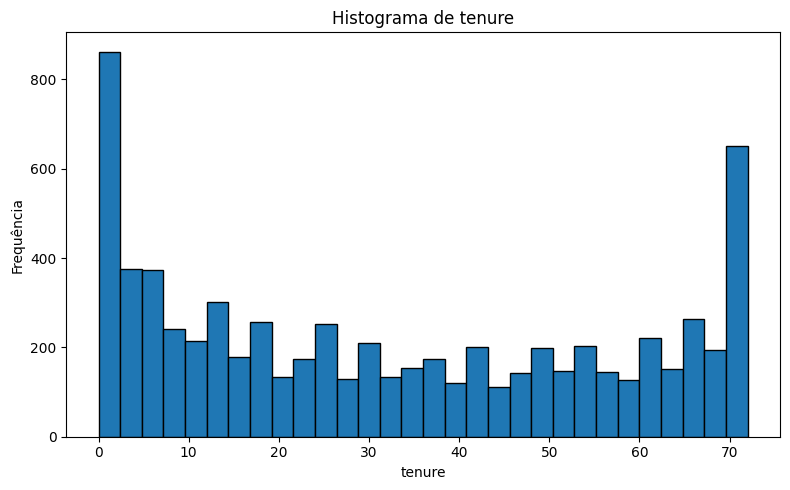

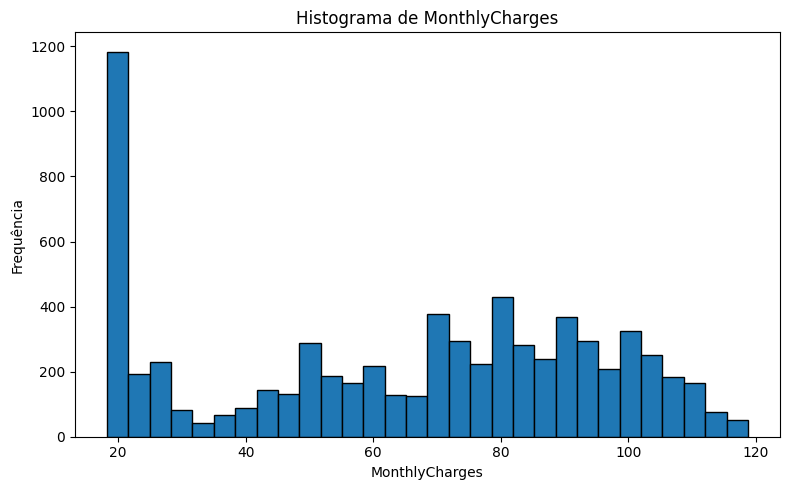

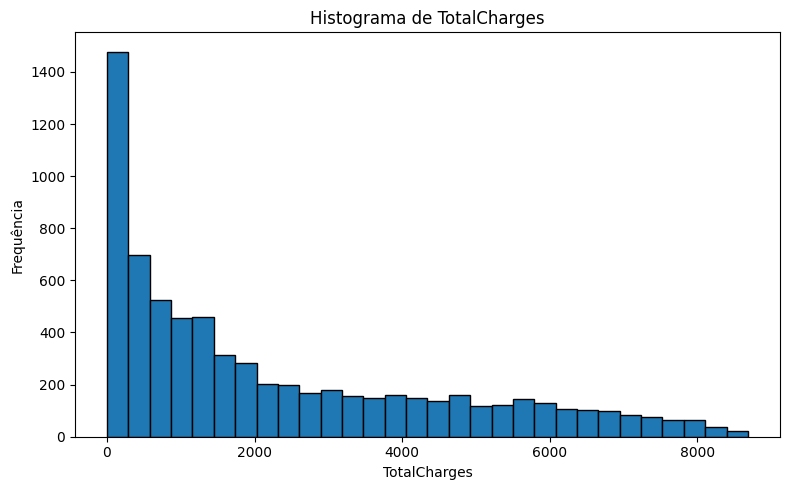

In [6]:
# Histogramas das variáveis numéricas

numeric_vars = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_vars:
    plt.figure(figsize=(8, 5))
    plt.hist(df_m2[col].dropna(), bins=30, edgecolor="black")
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.tight_layout()
    
    # Guardar figura
    plt.savefig(figures_path / f"histograma_{col}.png", dpi=300)
    
    plt.show()

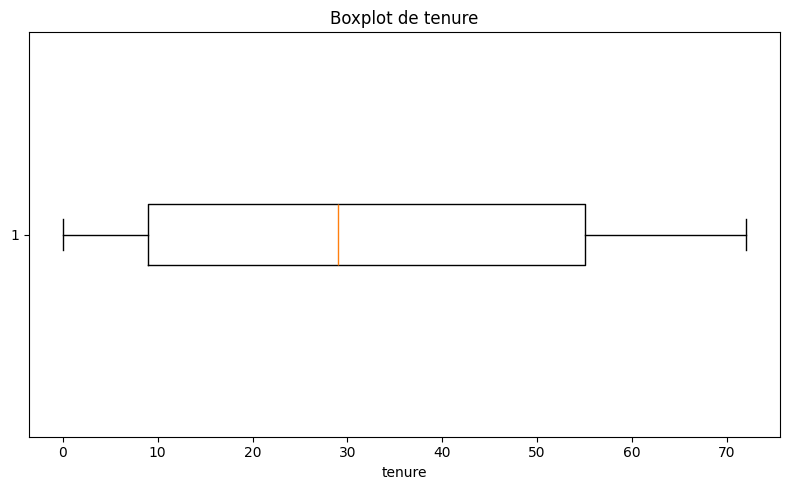

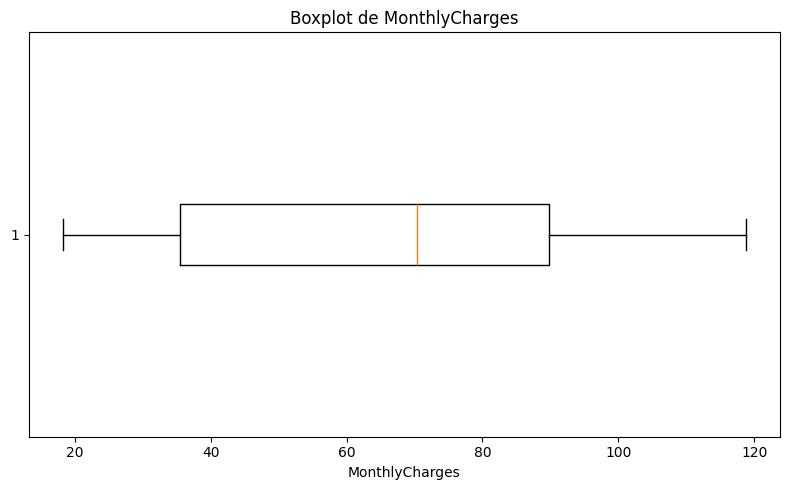

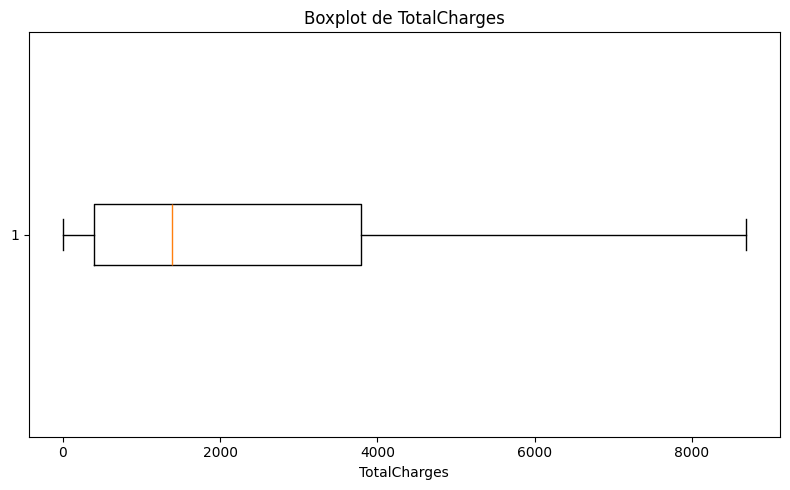

In [7]:
# Boxplots das variáveis numéricas

for col in numeric_vars:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df_m2[col].dropna(), vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    
    # Guardar figura
    plt.savefig(figures_path / f"boxplot_{col}.png", dpi=300)
    
    plt.show()

In [8]:
# Estatísticas descritivas das variáveis numéricas

numeric_summary = df_m2[numeric_vars].describe().T

numeric_summary["amplitude"] = numeric_summary["max"] - numeric_summary["min"]
numeric_summary["coef_variacao"] = numeric_summary["std"] / numeric_summary["mean"]

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,amplitude,coef_variacao
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00,72.0,0.758684
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75,100.5,0.464627
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80,8684.8,0.994324


## 2. Frequência das variáveis categóricas

Nesta secção são analisadas as frequências das variáveis categóricas. A variável `customerID` foi excluída por ser apenas um identificador. A variável `Churn` também foi excluída desta análise principal, porque o projeto está orientado para segmentação não supervisionada e não para classificação.

In [9]:
# Frequências das variáveis categóricas

# Identificar variáveis categóricas
categorical_vars = df_m2.select_dtypes(include="object").columns.tolist()

# Remover identificador e Churn da análise principal
categorical_vars = [
    col for col in categorical_vars 
    if col not in ["customerID", "Churn"]
]

print("Variáveis categóricas analisadas:")
print(categorical_vars)

for col in categorical_vars:
    print(f"\nFrequência absoluta e relativa de {col}:")
    
    freq_table = pd.DataFrame({
        "Contagem": df_m2[col].value_counts(),
        "Percentagem": df_m2[col].value_counts(normalize=True) * 100
    })
    
    freq_table["Percentagem"] = freq_table["Percentagem"].round(2)
    
    display(freq_table)

Variáveis categóricas analisadas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Frequência absoluta e relativa de gender:


,Contagem,Percentagem
gender,,
Male,3555,50.48
Female,3488,49.52



Frequência absoluta e relativa de Partner:


,Contagem,Percentagem
Partner,,
No,3641,51.7
Yes,3402,48.3



Frequência absoluta e relativa de Dependents:


...

,Contagem,Percentagem
Contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91



Frequência absoluta e relativa de PaperlessBilling:


,Contagem,Percentagem
PaperlessBilling,,
Yes,4171,59.22
No,2872,40.78



Frequência absoluta e relativa de PaymentMethod:


,Contagem,Percentagem
PaymentMethod,,
Electronic check,2365,33.58
Mailed check,1612,22.89
Bank transfer (automatic),1544,21.92
Credit card (automatic),1522,21.61


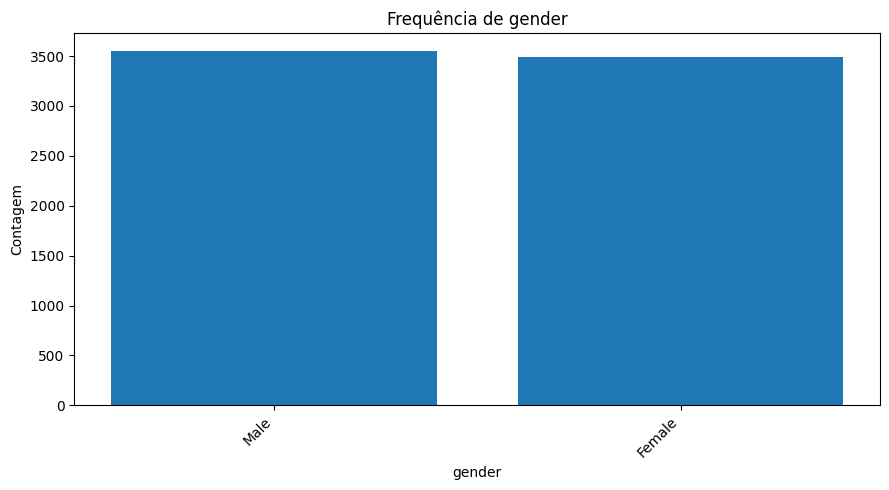

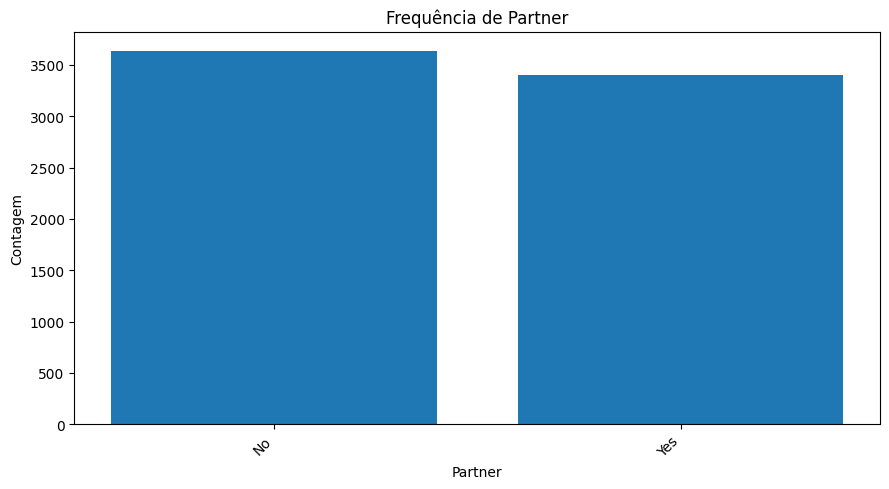

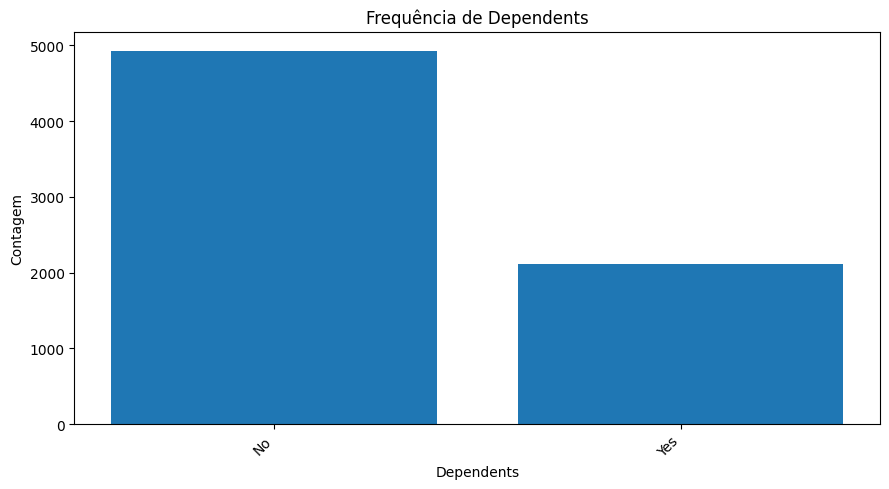

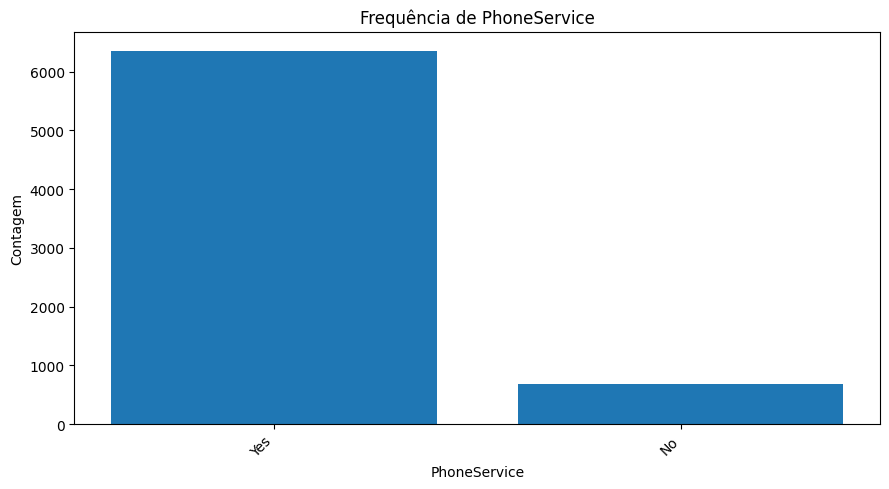

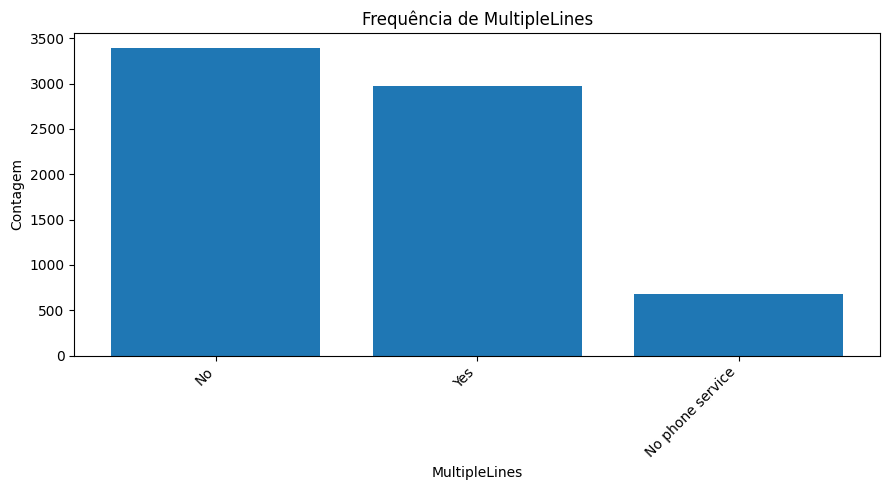

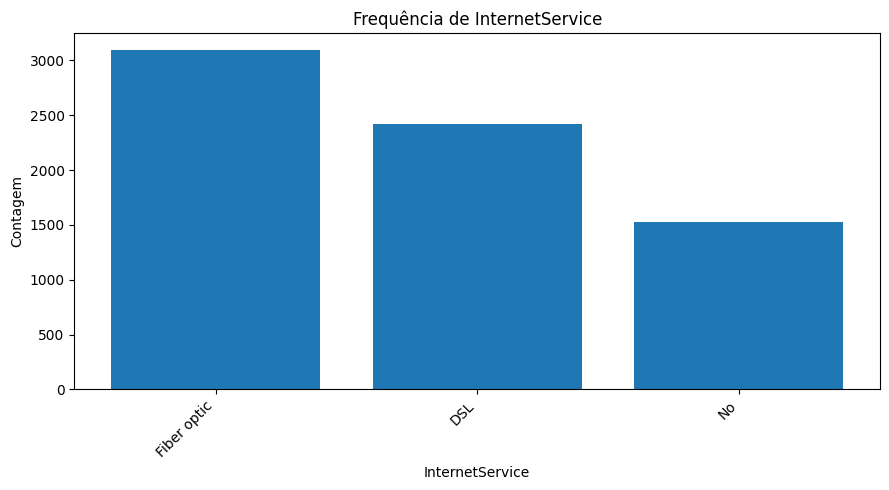

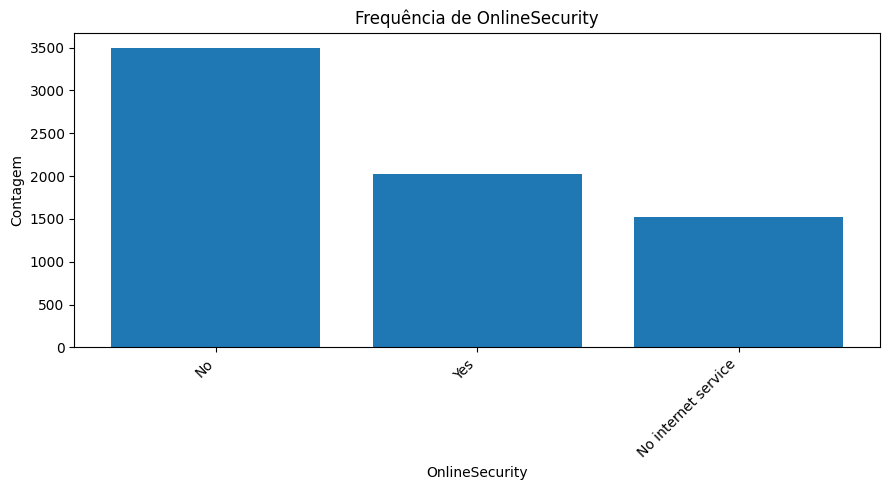

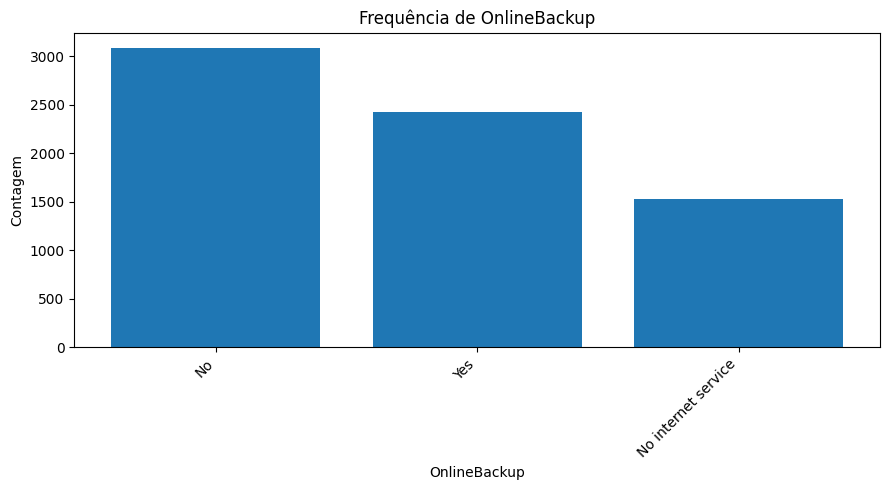

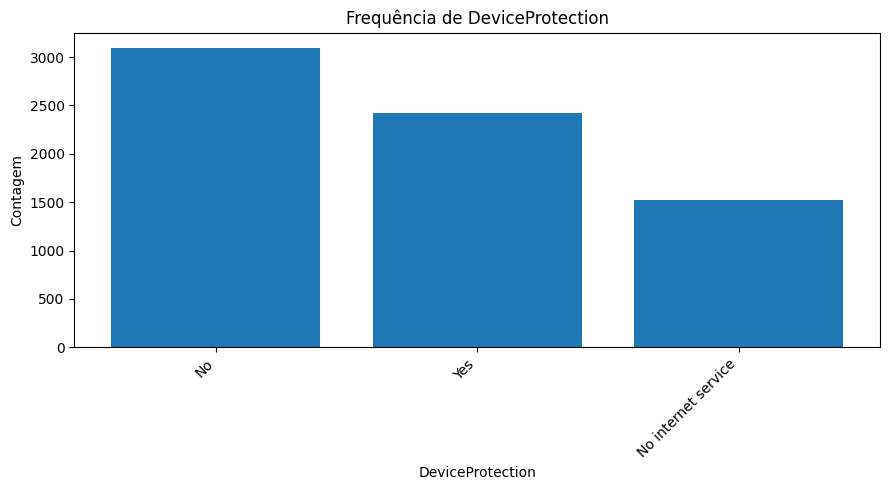

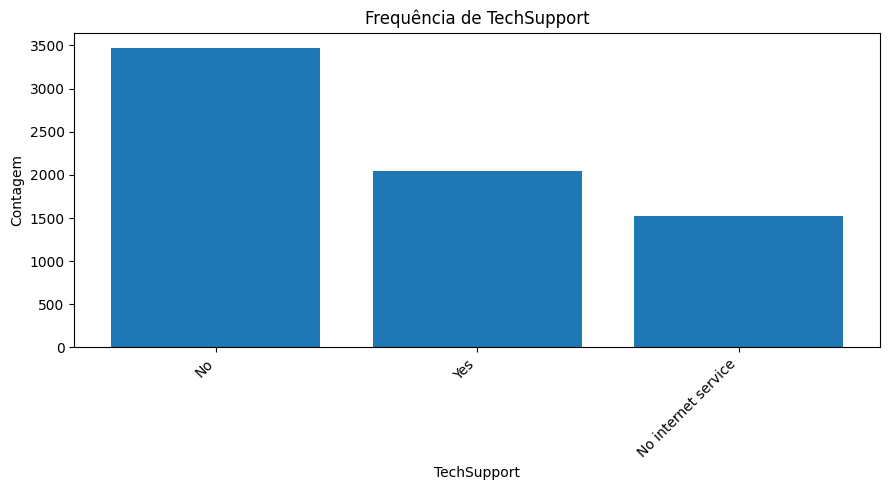

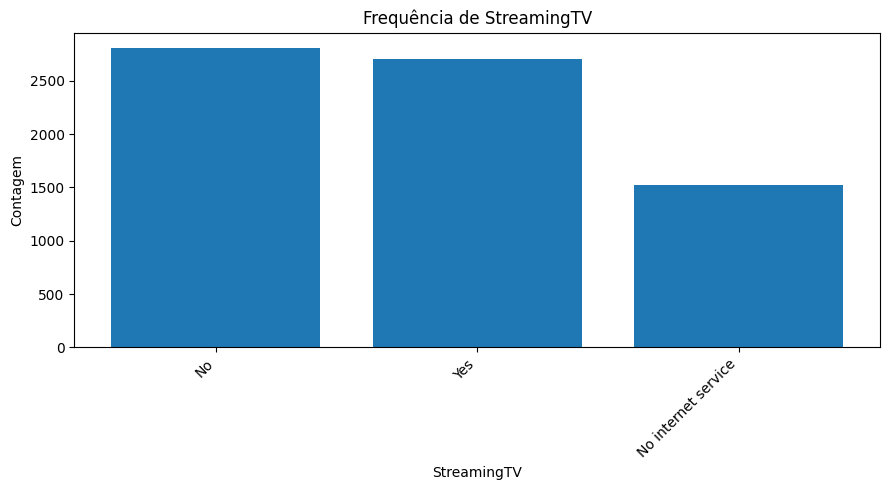

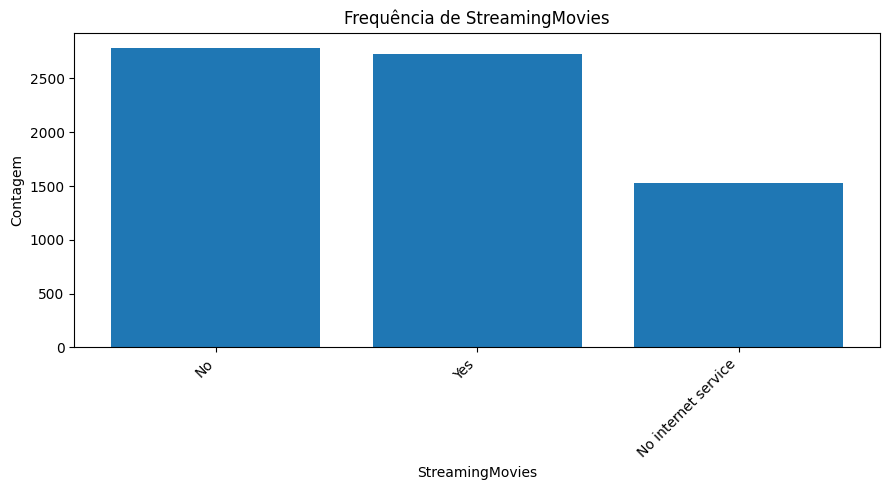

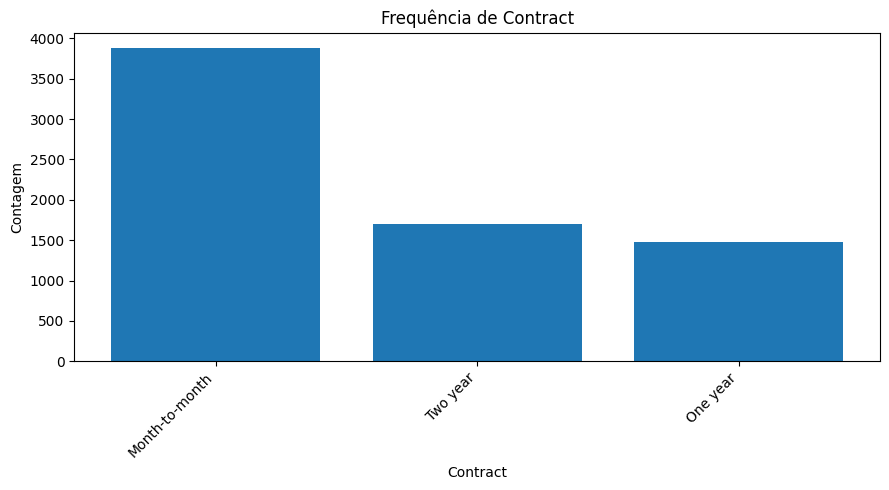

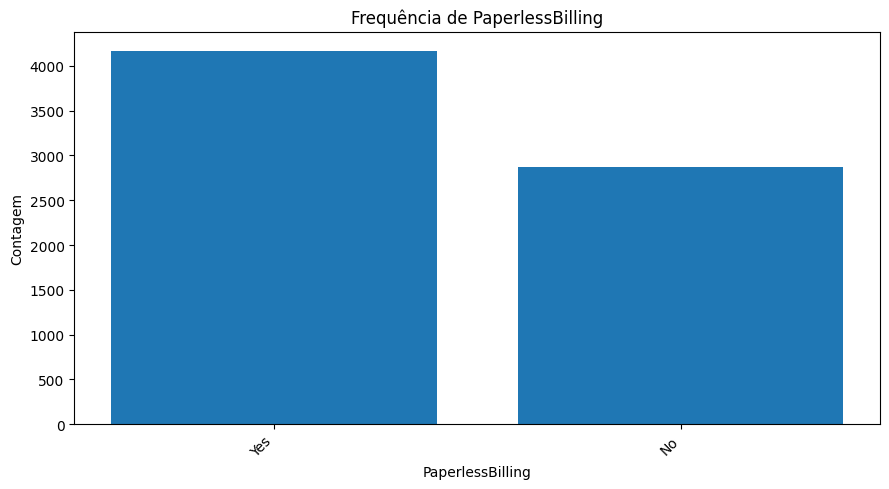

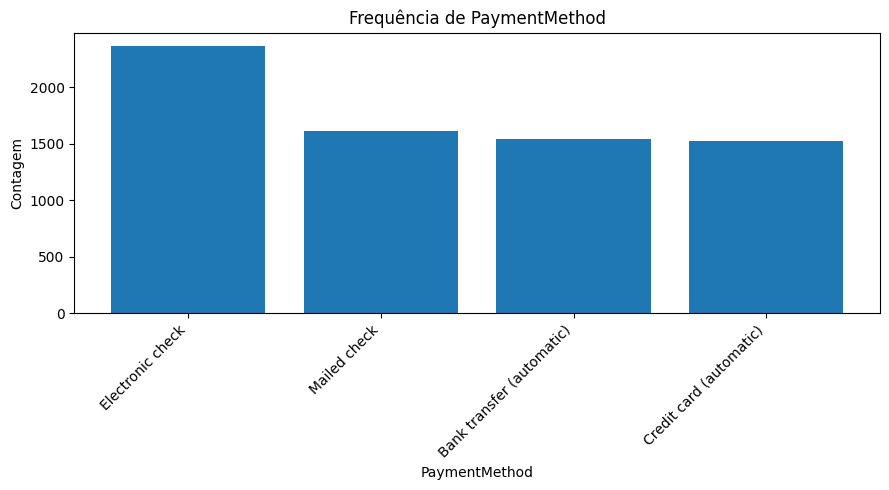

In [10]:
# Gráficos de barras das variáveis categóricas

for col in categorical_vars:
    plt.figure(figsize=(9, 5))
    
    counts = df_m2[col].value_counts()
    
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Frequência de {col}")
    plt.xlabel(col)
    plt.ylabel("Contagem")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    
    # Guardar figura
    safe_col_name = col.replace(" ", "_").replace("/", "_")
    plt.savefig(figures_path / f"frequencia_{safe_col_name}.png", dpi=300)
    
    plt.show()

## 3. Variáveis críticas para diferenciação dos clientes

Como o projeto segue uma abordagem não supervisionada, o foco não está em prever uma variável-alvo, mas sim em identificar variáveis que ajudam a diferenciar grupos de clientes.

Nesta fase, são consideradas especialmente relevantes as variáveis associadas a:

- tempo de permanência do cliente;
- valor mensal pago;
- valor total acumulado;
- tipo de contrato;
- serviços contratados;
- método de pagamento e faturação.

In [11]:
# Análise das variáveis numéricas mais diferenciadoras

critical_numeric_analysis = numeric_summary[
    ["mean", "std", "min", "max", "amplitude", "coef_variacao"]
].copy()

critical_numeric_analysis = critical_numeric_analysis.sort_values(
    by="coef_variacao", 
    ascending=False
)

display(critical_numeric_analysis)

,mean,std,min,max,amplitude,coef_variacao
TotalCharges,2279.734304,2266.794470,0.00,8684.80,8684.8,0.994324
tenure,32.371149,24.559481,0.00,72.00,72.0,0.758684
MonthlyCharges,64.761692,30.090047,18.25,118.75,100.5,0.464627


In [12]:
# Variáveis categóricas relevantes para segmentação

business_relevant_categoricals = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
    "MultipleLines"
]

# Garantir que só são usadas colunas existentes no dataset
business_relevant_categoricals = [
    col for col in business_relevant_categoricals 
    if col in df_m2.columns
]

for col in business_relevant_categoricals:
    print(f"\nDistribuição de {col}:")
    
    freq = pd.DataFrame({
        "Contagem": df_m2[col].value_counts(),
        "Percentagem": (df_m2[col].value_counts(normalize=True) * 100).round(2)
    })
    
    display(freq)


Distribuição de Contract:


,Contagem,Percentagem
Contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91



Distribuição de InternetService:


,Contagem,Percentagem
InternetService,,
Fiber optic,3096,43.96
DSL,2421,34.37
No,1526,21.67



Distribuição de PaymentMethod:


...

,Contagem,Percentagem
TechSupport,,
No,3473,49.31
Yes,2044,29.02
No internet service,1526,21.67



Distribuição de PaperlessBilling:


,Contagem,Percentagem
PaperlessBilling,,
Yes,4171,59.22
No,2872,40.78



Distribuição de MultipleLines:


,Contagem,Percentagem
MultipleLines,,
No,3390,48.13
Yes,2971,42.18
No phone service,682,9.68


## 4. Síntese da análise univariada

A análise das variáveis numéricas permitiu observar a distribuição de `tenure`, `MonthlyCharges` e `TotalCharges`, que são variáveis importantes para diferenciar clientes com diferentes níveis de permanência e valor económico.

A análise das variáveis categóricas permitiu observar a distribuição dos tipos de contrato, serviços contratados, métodos de pagamento e opções de faturação. Estas variáveis serão relevantes para a fase seguinte, uma vez que podem contribuir para a formação de segmentos de clientes com características distintas.

Durante esta fase também foi corrigido o tipo de dados da variável `TotalCharges`, que inicialmente estava lida como texto. Após a conversão para numérico, os valores em falta foram analisados e tratados quando associados a clientes com `tenure = 0`.

A variável `Churn` não foi utilizada como variável-alvo, mantendo a coerência com a abordagem não supervisionada do projeto.

## 5. Análise Bivariada e Correlações

Nesta secção é realizada uma análise bivariada para estudar relações entre variáveis relevantes para a segmentação de clientes.

Como o projeto segue uma abordagem de aprendizagem não supervisionada, não será utilizada uma variável-alvo de classificação. Assim, em vez de analisar relações com `Churn`, serão analisadas relações entre variáveis críticas para a diferenciação dos clientes, nomeadamente `tenure`, `MonthlyCharges` e `TotalCharges`.

O objetivo é perceber se existem relações factuais entre atributos que possam influenciar a formação de perfis de clientes.

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# Garantir que a pasta de figuras existe
figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
tenure,1.000000,0.247900,0.826178,0.016567
MonthlyCharges,0.247900,1.000000,0.651174,0.220173
TotalCharges,0.826178,0.651174,1.000000,0.103006
SeniorCitizen,0.016567,0.220173,0.103006,1.000000


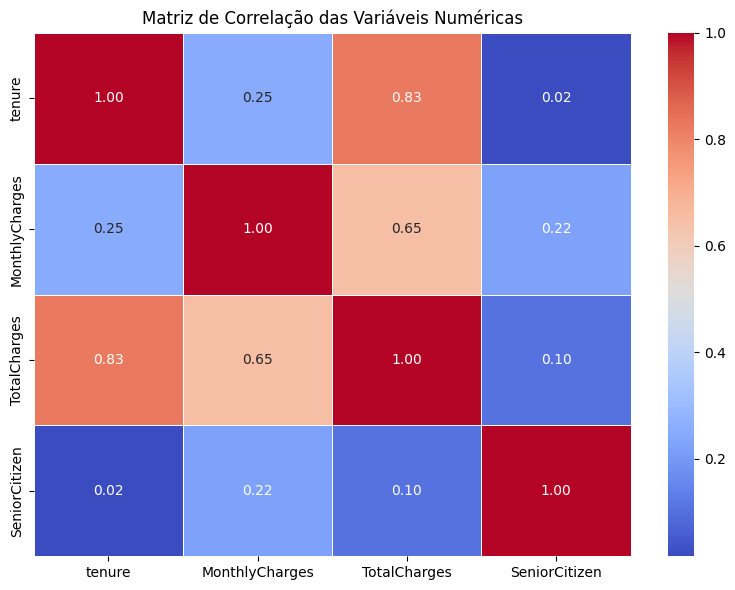

In [14]:
# Matriz de correlação das variáveis numéricas

# Selecionar variáveis numéricas relevantes para segmentação
corr_vars = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
]

# Garantir que só entram colunas existentes no dataframe
corr_vars = [col for col in corr_vars if col in df_m2.columns]

# Calcular matriz de correlação
corr_matrix = df_m2[corr_vars].corr()

display(corr_matrix)

# Criar heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.tight_layout()

# Guardar figura
plt.savefig(figures_path / "heatmap_correlacao_variaveis_numericas.png", dpi=300)

plt.show()

### Interpretação da matriz de correlação

A matriz de correlação permite observar relações lineares entre as principais variáveis numéricas do dataset.

A relação entre `tenure` e `TotalCharges` tende a ser positiva, o que é esperado, uma vez que clientes com maior tempo de permanência acumulam normalmente encargos totais mais elevados.

A variável `MonthlyCharges` também pode apresentar relação positiva com `TotalCharges`, pois clientes com encargos mensais mais altos tendem a acumular valores totais superiores ao longo do tempo.

Estas relações são relevantes para a segmentação, porque ajudam a distinguir clientes com diferentes níveis de permanência, valor mensal e valor acumulado.

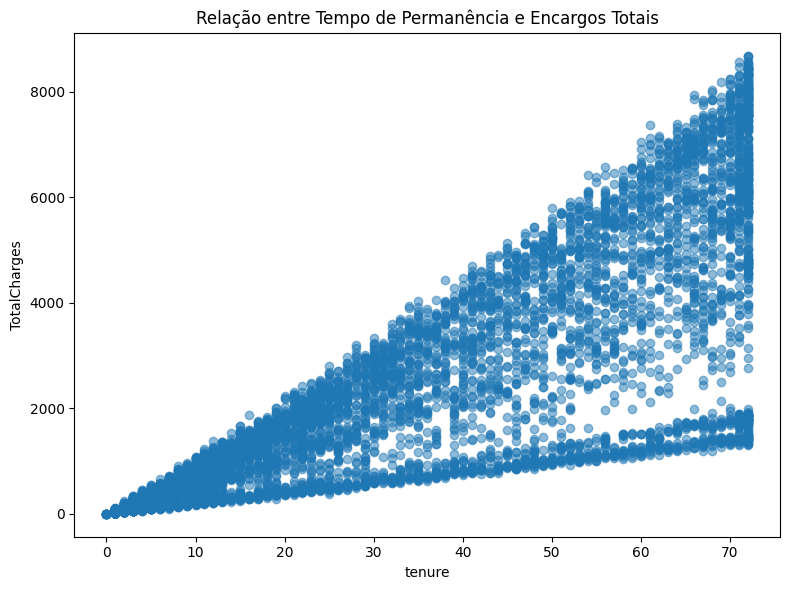

In [15]:
# Scatter plot: tenure vs TotalCharges

plt.figure(figsize=(8, 6))

plt.scatter(
    df_m2["tenure"],
    df_m2["TotalCharges"],
    alpha=0.5
)

plt.title("Relação entre Tempo de Permanência e Encargos Totais")
plt.xlabel("tenure")
plt.ylabel("TotalCharges")
plt.tight_layout()

# Guardar figura
plt.savefig(figures_path / "scatter_tenure_totalcharges.png", dpi=300)

plt.show()

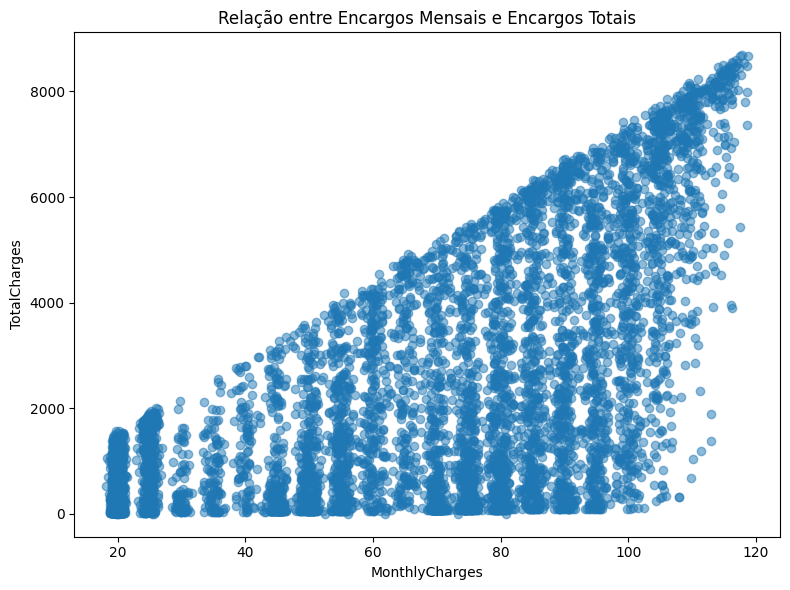

In [16]:
# Scatter plot: MonthlyCharges vs TotalCharges

plt.figure(figsize=(8, 6))

plt.scatter(
    df_m2["MonthlyCharges"],
    df_m2["TotalCharges"],
    alpha=0.5
)

plt.title("Relação entre Encargos Mensais e Encargos Totais")
plt.xlabel("MonthlyCharges")
plt.ylabel("TotalCharges")
plt.tight_layout()

# Guardar figura
plt.savefig(figures_path / "scatter_monthlycharges_totalcharges.png", dpi=300)

plt.show()

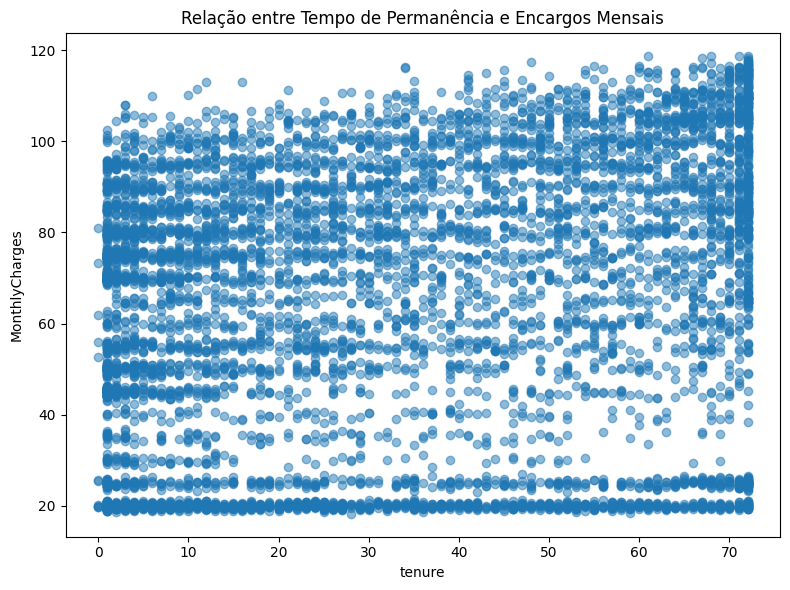

In [17]:
# Scatter plot: tenure vs MonthlyCharges

plt.figure(figsize=(8, 6))

plt.scatter(
    df_m2["tenure"],
    df_m2["MonthlyCharges"],
    alpha=0.5
)

plt.title("Relação entre Tempo de Permanência e Encargos Mensais")
plt.xlabel("tenure")
plt.ylabel("MonthlyCharges")
plt.tight_layout()

# Guardar figura
plt.savefig(figures_path / "scatter_tenure_monthlycharges.png", dpi=300)

plt.show()

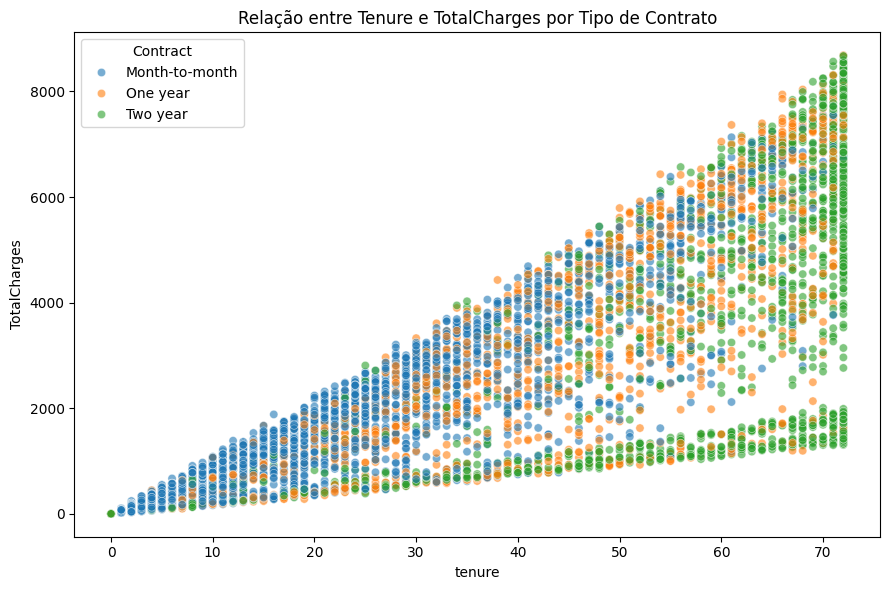

In [18]:
# Scatter plot com diferenciação por tipo de contrato

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_m2,
    x="tenure",
    y="TotalCharges",
    hue="Contract",
    alpha=0.6
)

plt.title("Relação entre Tenure e TotalCharges por Tipo de Contrato")
plt.xlabel("tenure")
plt.ylabel("TotalCharges")
plt.legend(title="Contract")
plt.tight_layout()

# Guardar figura
plt.savefig(figures_path / "scatter_tenure_totalcharges_contract.png", dpi=300)

plt.show()

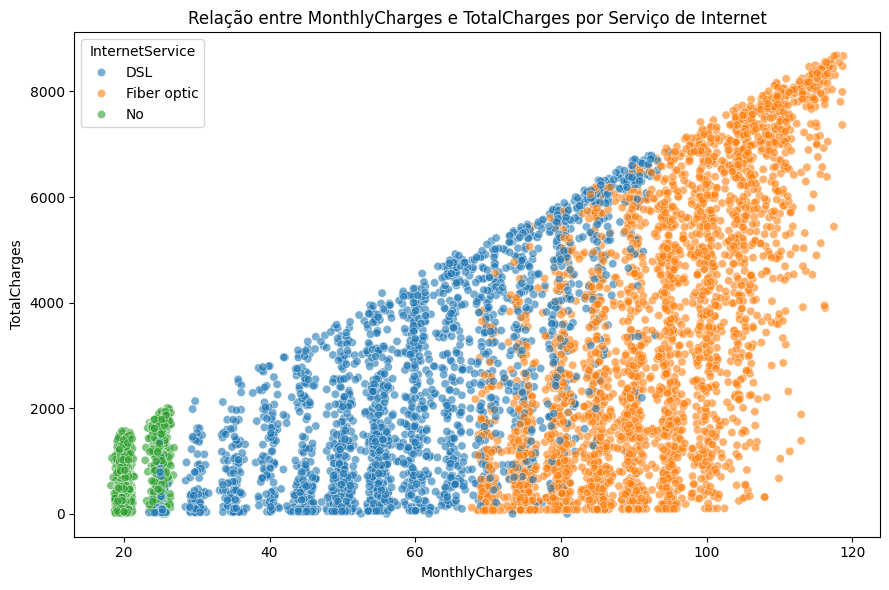

In [19]:
# Scatter plot com diferenciação por serviço de Internet

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_m2,
    x="MonthlyCharges",
    y="TotalCharges",
    hue="InternetService",
    alpha=0.6
)

plt.title("Relação entre MonthlyCharges e TotalCharges por Serviço de Internet")
plt.xlabel("MonthlyCharges")
plt.ylabel("TotalCharges")
plt.legend(title="InternetService")
plt.tight_layout()

# Guardar figura
plt.savefig(figures_path / "scatter_monthlycharges_totalcharges_internetservice.png", dpi=300)

plt.show()

In [20]:
# Correlações ordenadas entre variáveis numéricas

corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["Variável 1", "Variável 2", "Correlação"]

# Remover autocorrelações
corr_pairs = corr_pairs[corr_pairs["Variável 1"] != corr_pairs["Variável 2"]]

# Evitar pares duplicados
corr_pairs["Par"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["Variável 1"], row["Variável 2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates("Par").drop(columns="Par")

# Ordenar por valor absoluto da correlação
corr_pairs["Correlação Absoluta"] = corr_pairs["Correlação"].abs()

corr_pairs = corr_pairs.sort_values(
    by="Correlação Absoluta",
    ascending=False
)

display(corr_pairs)

,Variável 1,Variável 2,Correlação,Correlação Absoluta
2,tenure,TotalCharges,0.826178,0.826178
6,MonthlyCharges,TotalCharges,0.651174,0.651174
1,tenure,MonthlyCharges,0.247900,0.247900
7,MonthlyCharges,SeniorCitizen,0.220173,0.220173
11,TotalCharges,SeniorCitizen,0.103006,0.103006
3,tenure,SeniorCitizen,0.016567,0.016567


### Síntese da análise bivariada

A análise bivariada mostrou relações relevantes entre algumas variáveis numéricas importantes para a segmentação.

A relação entre `tenure` e `TotalCharges` é particularmente importante, uma vez que clientes com maior tempo de permanência tendem a apresentar encargos totais superiores. Esta relação é coerente com a lógica do negócio, pois quanto mais tempo um cliente permanece na empresa, maior tende a ser o valor acumulado pago.

Também foi analisada a relação entre `MonthlyCharges` e `TotalCharges`, permitindo observar diferenças entre clientes com diferentes níveis de encargos mensais e valor total acumulado.

Os gráficos de dispersão com `Contract` e `InternetService` ajudam a perceber como variáveis contratuais e de serviços subscritos podem diferenciar grupos de clientes. Estas variáveis serão relevantes para a fase de preparação e modelação, onde o objetivo será identificar 3 perfis de clientes estatisticamente caracterizáveis.

## 6. Tratamento de Dados em Falta — Missing Data

Nesta secção é analisada a existência de valores em falta no dataset.

O objetivo é identificar a percentagem de valores nulos por coluna e definir uma estratégia de tratamento adequada, garantindo que o dataset fica preparado para a fase de modelação.

Como o projeto segue uma abordagem de segmentação não supervisionada, o tratamento de dados em falta será aplicado às variáveis relevantes para a diferenciação dos clientes, sem tratar `Churn` como variável-alvo.

In [21]:
# Tratamento de Dados em Falta — Missing Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Garantir que existe uma cópia para a Milestone 2
try:
    df_m2
except NameError:
    df_m2 = df.copy()

# Garantir que a pasta de figuras existe
figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

# Percentagem de valores em falta antes de qualquer tratamento
missing_summary_before = pd.DataFrame({
    "Valores em falta": df_m2.isna().sum(),
    "Percentagem (%)": (df_m2.isna().mean() * 100).round(2)
})

missing_summary_before = missing_summary_before.sort_values(
    by="Percentagem (%)",
    ascending=False
)

display(missing_summary_before)

,Valores em falta,Percentagem (%)
TotalCharges_num,11,0.16
customerID,0,0.00
SeniorCitizen,0,0.00
Partner,0,0.00
Dependents,0,0.00
gender,0,0.00
tenure,0,0.00
PhoneService,0,0.00
InternetService,0,0.00
MultipleLines,0,0.00


In [22]:
# Conversão de TotalCharges para numérico

# Converter TotalCharges para numérico
# Valores inválidos ou espaços em branco passam a NaN
df_m2["TotalCharges"] = pd.to_numeric(df_m2["TotalCharges"], errors="coerce")

# Verificar novamente os valores em falta depois da conversão
missing_summary_after_conversion = pd.DataFrame({
    "Valores em falta": df_m2.isna().sum(),
    "Percentagem (%)": (df_m2.isna().mean() * 100).round(2)
})

missing_summary_after_conversion = missing_summary_after_conversion.sort_values(
    by="Percentagem (%)",
    ascending=False
)

display(missing_summary_after_conversion)

print("Linhas com TotalCharges em falta após conversão:")
display(
    df_m2[df_m2["TotalCharges"].isna()][
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
    ]
)

,Valores em falta,Percentagem (%)
TotalCharges_num,11,0.16
customerID,0,0.00
SeniorCitizen,0,0.00
Partner,0,0.00
Dependents,0,0.00
gender,0,0.00
tenure,0,0.00
PhoneService,0,0.00
InternetService,0,0.00
MultipleLines,0,0.00


Linhas com TotalCharges em falta após conversão:


,customerID,tenure,MonthlyCharges,TotalCharges


In [23]:
# Análise dos valores em falta em TotalCharges

missing_totalcharges = df_m2[df_m2["TotalCharges"].isna()]

print("Número de valores em falta em TotalCharges:")
print(len(missing_totalcharges))

print("\nDistribuição de tenure nas linhas com TotalCharges em falta:")
display(missing_totalcharges["tenure"].value_counts().sort_index().to_frame("Contagem"))

# Verificar se todos os nulos de TotalCharges correspondem a tenure = 0
all_missing_have_tenure_zero = (missing_totalcharges["tenure"] == 0).all()
print(all_missing_have_tenure_zero)

Número de valores em falta em TotalCharges:
0

Distribuição de tenure nas linhas com TotalCharges em falta:


,Contagem
tenure,


True


In [24]:
# Estratégia de tratamento de valores em falta

# 1. TotalCharges:
# Se TotalCharges está em falta e tenure = 0, então TotalCharges é preenchido com 0.
# Justificação: clientes com tenure = 0 ainda não acumularam encargos totais.

condition_totalcharges_zero = df_m2["TotalCharges"].isna() & (df_m2["tenure"] == 0)

df_m2.loc[condition_totalcharges_zero, "TotalCharges"] = 0

print("Valores de TotalCharges preenchidos com 0:")
print(condition_totalcharges_zero.sum())


# 2. Restantes valores numéricos em falta:
# Usar mediana, porque é menos sensível a outliers do que a média.

numeric_cols = df_m2.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in numeric_cols:
    if df_m2[col].isna().sum() > 0:
        median_value = df_m2[col].median()
        df_m2[col] = df_m2[col].fillna(median_value)
        print(f"Coluna numérica '{col}' preenchida com mediana: {median_value}")


# 3. Restantes valores categóricos em falta:
# Usar moda, porque representa a categoria mais frequente.

categorical_cols = df_m2.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    if df_m2[col].isna().sum() > 0:
        mode_value = df_m2[col].mode()[0]
        df_m2[col] = df_m2[col].fillna(mode_value)
        print(f"Coluna categórica '{col}' preenchida com moda: {mode_value}")

Valores de TotalCharges preenchidos com 0:
0
Coluna numérica 'TotalCharges_num' preenchida com mediana: 1397.475


In [25]:
# Verificação final dos valores em falta

missing_summary_after = pd.DataFrame({
    "Valores em falta": df_m2.isna().sum(),
    "Percentagem (%)": (df_m2.isna().mean() * 100).round(2)
})

missing_summary_after = missing_summary_after.sort_values(
    by="Percentagem (%)",
    ascending=False
)

display(missing_summary_after)

print("Total de valores em falta no dataset após tratamento:")
print(df_m2.isna().sum().sum())

,Valores em falta,Percentagem (%)
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


Total de valores em falta no dataset após tratamento:
0


In [26]:
# Guardar dataset após tratamento de valores em falta

processed_path = Path("data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

output_file = processed_path / "telco_customer_churn_m2_missing_tratado.csv"

df_m2.to_csv(output_file, index=False)

print(f"Dataset guardado em: {output_file}")
print(f"Dimensão final: {df_m2.shape[0]} linhas e {df_m2.shape[1]} colunas")

Dataset guardado em: data/processed/telco_customer_churn_m2_missing_tratado.csv
Dimensão final: 7043 linhas e 22 colunas


### Síntese do tratamento de dados em falta

Foi analisada a percentagem de valores em falta por coluna. Após a conversão da variável `TotalCharges` para formato numérico, foram identificados valores em falta associados a registos onde esta variável não estava corretamente representada como número.

A estratégia adotada foi preencher `TotalCharges` com 0 quando o cliente apresentava `tenure = 0`, uma vez que clientes sem tempo de permanência ainda não acumularam encargos totais.

Para eventuais valores em falta em variáveis numéricas, foi definida a mediana como estratégia de imputação, por ser menos sensível a valores extremos do que a média. Para eventuais valores em falta em variáveis categóricas, foi definida a moda como estratégia de imputação, por representar a categoria mais frequente.

Após o tratamento, foi confirmada a inexistência de valores em falta no dataset preparado para as próximas fases da Milestone 2.

## 7. Tratamento de Outliers e Erros nos Dados

Nesta secção são analisados possíveis valores atípicos e erros no reconhecimento dos tipos de dados.

Como o projeto tem como objetivo construir um modelo descritivo de segmentação de clientes, é importante garantir que as variáveis numéricas estão corretamente representadas e que valores extremos não enviesam a formação dos perfis.

A análise será focada nas principais variáveis numéricas relevantes para a segmentação:

- `tenure`;
- `MonthlyCharges`;
- `TotalCharges`.

Também será verificado se existem erros de tipo, como variáveis numéricas lidas como texto.

In [27]:
# Verificação dos tipos de dados

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Garantir que existe uma cópia para a Milestone 2
try:
    df_m2
except NameError:
    df_m2 = df.copy()

# Criar pasta para guardar figuras
figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

# Verificar tipos de dados
data_types = pd.DataFrame({
    "Coluna": df_m2.columns,
    "Tipo de dados": df_m2.dtypes.astype(str),
    "Valores únicos": df_m2.nunique().values,
    "Valores em falta": df_m2.isna().sum().values
})

display(data_types)

,Coluna,Tipo de dados,Valores únicos,Valores em falta
customerID,customerID,object,7043,0
gender,gender,object,2,0
SeniorCitizen,SeniorCitizen,int64,2,0
Partner,Partner,object,2,0
Dependents,Dependents,object,2,0
tenure,tenure,int64,73,0
PhoneService,PhoneService,object,2,0
MultipleLines,MultipleLines,object,3,0
InternetService,InternetService,object,3,0
OnlineSecurity,OnlineSecurity,object,3,0


In [28]:
# Correção do tipo de dados da variável TotalCharges

print("Tipo de dados de TotalCharges antes da conversão:")
print(df_m2["TotalCharges"].dtype)

# Converter TotalCharges para numérico
df_m2["TotalCharges"] = pd.to_numeric(df_m2["TotalCharges"], errors="coerce")

print("\nTipo de dados de TotalCharges depois da conversão:")
print(df_m2["TotalCharges"].dtype)

print("\nValores em falta em TotalCharges após conversão:")
print(df_m2["TotalCharges"].isna().sum())

# Caso existam valores em falta com tenure = 0, preencher com 0
condition_totalcharges_zero = df_m2["TotalCharges"].isna() & (df_m2["tenure"] == 0)

df_m2.loc[condition_totalcharges_zero, "TotalCharges"] = 0

print("\nValores de TotalCharges preenchidos com 0:")
print(condition_totalcharges_zero.sum())

print("\nValores em falta em TotalCharges após tratamento:")
print(df_m2["TotalCharges"].isna().sum())

Tipo de dados de TotalCharges antes da conversão:
float64

Tipo de dados de TotalCharges depois da conversão:
float64

Valores em falta em TotalCharges após conversão:
0

Valores de TotalCharges preenchidos com 0:
0

Valores em falta em TotalCharges após tratamento:
0


In [29]:
# Verificação de valores impossíveis ou incoerentes

numeric_vars = ["tenure", "MonthlyCharges", "TotalCharges"]

# Garantir que só entram colunas existentes
numeric_vars = [col for col in numeric_vars if col in df_m2.columns]

range_check = pd.DataFrame({
    "Mínimo": df_m2[numeric_vars].min(),
    "Máximo": df_m2[numeric_vars].max(),
    "Média": df_m2[numeric_vars].mean(),
    "Mediana": df_m2[numeric_vars].median(),
    "Desvio padrão": df_m2[numeric_vars].std()
})

display(range_check)

# Verificar valores negativos
for col in numeric_vars:
    negative_count = (df_m2[col] < 0).sum()
    print(f"{col}: {negative_count} valores negativos")

,Mínimo,Máximo,Média,Mediana,Desvio padrão
tenure,0.00,72.00,32.371149,29.00,24.559481
MonthlyCharges,18.25,118.75,64.761692,70.35,30.090047
TotalCharges,0.00,8684.80,2279.734304,1394.55,2266.794470


tenure: 0 valores negativos
MonthlyCharges: 0 valores negativos
TotalCharges: 0 valores negativos


In [30]:
# Identificação de outliers pelo método IQR

outlier_summary = []

for col in numeric_vars:
    Q1 = df_m2[col].quantile(0.25)
    Q3 = df_m2[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df_m2[(df_m2[col] < lower_limit) | (df_m2[col] > upper_limit)]
    
    outlier_summary.append({
        "Variável": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Limite inferior": lower_limit,
        "Limite superior": upper_limit,
        "N.º de outliers": len(outliers),
        "Percentagem de outliers (%)": round(len(outliers) / len(df_m2) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)

,Variável,Q1,Q3,IQR,Limite inferior,Limite superior,N.º de outliers,Percentagem de outliers (%)
0,tenure,9.00,55.00,46.00,-60.000,124.000,0,0.0
1,MonthlyCharges,35.50,89.85,54.35,-46.025,171.375,0,0.0
2,TotalCharges,398.55,3786.60,3388.05,-4683.525,8868.675,0,0.0


In [31]:
# Visualização dos registos considerados outliers

for col in numeric_vars:
    Q1 = df_m2[col].quantile(0.25)
    Q3 = df_m2[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df_m2[(df_m2[col] < lower_limit) | (df_m2[col] > upper_limit)]
    
    print(f"\nOutliers identificados em {col}: {len(outliers)}")
    
    if len(outliers) > 0:
        display(
            outliers[
                ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
            ].head(10)
        )


Outliers identificados em tenure: 0

Outliers identificados em MonthlyCharges: 0

Outliers identificados em TotalCharges: 0


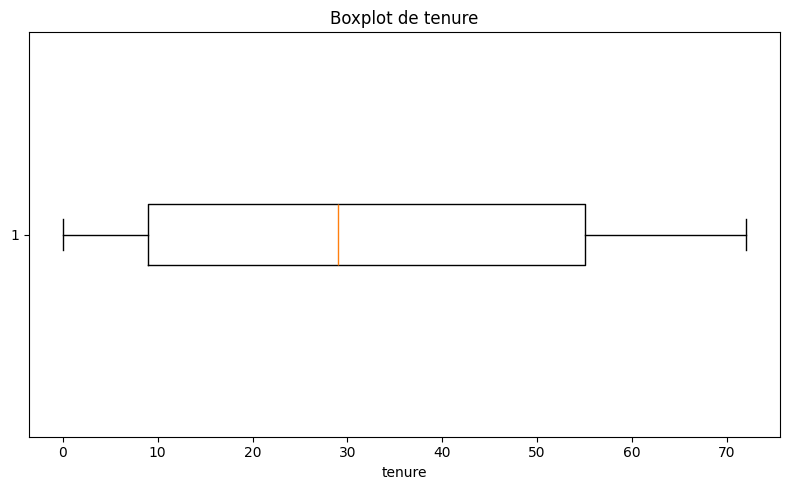

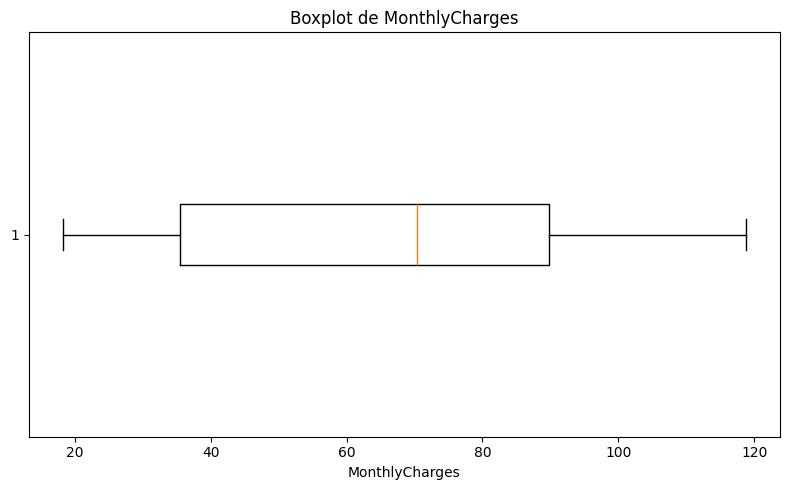

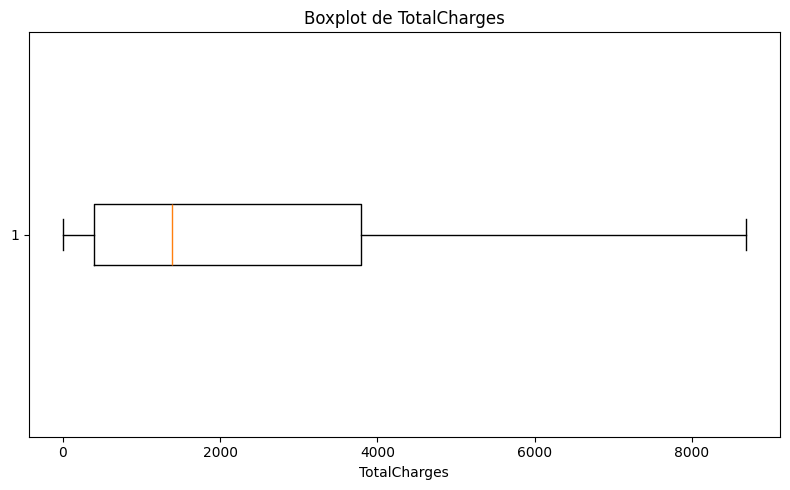

In [32]:
# Boxplots para identificação visual de outliers
for col in numeric_vars:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df_m2[col].dropna(), vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    
    plt.savefig(figures_path / f"boxplot_outliers_{col}.png", dpi=300)
    
    plt.show()

### Decisão sobre o tratamento dos outliers

Foram identificados possíveis valores atípicos através do método IQR e através de boxplots.

No entanto, os valores extremos encontrados nas variáveis `tenure`, `MonthlyCharges` e `TotalCharges` não foram automaticamente removidos, porque podem representar clientes reais com maior permanência, maior nível de serviços contratados ou maior valor económico acumulado.

A remoção automática destes valores poderia eliminar perfis relevantes para a segmentação. Assim, nesta fase, os outliers foram documentados e mantidos no dataset.

Na fase de preparação para modelação, será aplicado escalonamento às variáveis numéricas, de forma a reduzir o impacto das diferentes escalas entre atributos.

In [33]:
# Criação de variáveis indicadoras de outliers

for col in numeric_vars:
    Q1 = df_m2[col].quantile(0.25)
    Q3 = df_m2[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    df_m2[f"{col}_outlier"] = (
        (df_m2[col] < lower_limit) | 
        (df_m2[col] > upper_limit)
    ).astype(int)

outlier_flag_cols = [f"{col}_outlier" for col in numeric_vars]

display(df_m2[outlier_flag_cols].sum().to_frame("N.º de outliers sinalizados"))

,N.º de outliers sinalizados
tenure_outlier,0
MonthlyCharges_outlier,0
TotalCharges_outlier,0


In [34]:
# Verificação final dos tipos de dados após correções

final_data_types = pd.DataFrame({
    "Coluna": df_m2.columns,
    "Tipo de dados final": df_m2.dtypes.astype(str),
    "Valores em falta": df_m2.isna().sum().values
})

display(final_data_types)

,Coluna,Tipo de dados final,Valores em falta
customerID,customerID,object,0
gender,gender,object,0
SeniorCitizen,SeniorCitizen,int64,0
Partner,Partner,object,0
Dependents,Dependents,object,0
tenure,tenure,int64,0
PhoneService,PhoneService,object,0
MultipleLines,MultipleLines,object,0
InternetService,InternetService,object,0
OnlineSecurity,OnlineSecurity,object,0


In [35]:
# Guardar dataset após análise de outliers e correção de tipos

processed_path = Path("data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

output_file = processed_path / "telco_customer_churn_m2_outliers_tipos_tratados.csv"

df_m2.to_csv(output_file, index=False)

print(f"Dataset guardado em: {output_file}")
print(f"Dimensão final: {df_m2.shape[0]} linhas e {df_m2.shape[1]} colunas")

Dataset guardado em: data/processed/telco_customer_churn_m2_outliers_tipos_tratados.csv
Dimensão final: 7043 linhas e 25 colunas


## 8. Transformação de Variáveis

Nesta fase são aplicadas transformações às variáveis para preparar o dataset para a modelação não supervisionada.

Como os algoritmos de segmentação trabalham com valores numéricos, as variáveis categóricas serão transformadas através de One-Hot Encoding. Esta opção é adequada porque a maioria das variáveis categóricas do dataset não tem uma ordem natural.

As variáveis numéricas `tenure`, `MonthlyCharges` e `TotalCharges` serão escalonadas com StandardScaler, para que fiquem numa escala comparável. Esta transformação é importante porque algoritmos como K-Means são sensíveis à escala das variáveis.

A variável `customerID` será excluída por ser apenas um identificador. A variável `Churn` também será excluída, mantendo a coerência com a abordagem de aprendizagem não supervisionada.

In [36]:
# Transformação de Variáveis — Preparação Inicial

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# Garantir que existe uma cópia da Milestone 2
try:
    df_m2
except NameError:
    df_m2 = df.copy()

# Garantir que TotalCharges está em formato numérico
df_m2["TotalCharges"] = pd.to_numeric(df_m2["TotalCharges"], errors="coerce")

# Preencher TotalCharges com 0 quando tenure = 0
condition_totalcharges_zero = df_m2["TotalCharges"].isna() & (df_m2["tenure"] == 0)
df_m2.loc[condition_totalcharges_zero, "TotalCharges"] = 0

# Caso ainda existam nulos em TotalCharges, preencher com a mediana
if df_m2["TotalCharges"].isna().sum() > 0:
    df_m2["TotalCharges"] = df_m2["TotalCharges"].fillna(df_m2["TotalCharges"].median())

print("Valores em falta em TotalCharges após preparação:")
print(df_m2["TotalCharges"].isna().sum())

Valores em falta em TotalCharges após preparação:
0


In [37]:
# Seleção das variáveis para segmentação

# Variáveis demográficas
demographic_vars = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

# Variáveis contratuais
contractual_vars = [
    "tenure",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

# Variáveis de serviços subscritos
service_vars = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Variáveis de consumo / valor económico
consumption_vars = [
    "MonthlyCharges",
    "TotalCharges"
]

# Juntar variáveis segundo o Objetivo SMART
selected_vars = (
    demographic_vars
    + contractual_vars
    + service_vars
    + consumption_vars
)

# Garantir que só entram colunas existentes no dataframe
selected_vars = [col for col in selected_vars if col in df_m2.columns]

# Criar dataframe apenas com as variáveis selecionadas
df_transform = df_m2[selected_vars].copy()

print("Variáveis selecionadas para transformação:")
print(selected_vars)

print("\nDimensão antes da transformação:")
print(df_transform.shape)

display(df_transform.head())

Variáveis selecionadas para transformação:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MonthlyCharges', 'TotalCharges']

Dimensão antes da transformação:
(7043, 19)


,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaperlessBilling,PaymentMethod,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,Month-to-month,Yes,Electronic check,No,No phone service,DSL,No,Yes,No,No,No,No,29.85,29.85
1,Male,0,No,No,34,One year,No,Mailed check,Yes,No,DSL,Yes,No,Yes,No,No,No,56.95,1889.50
2,Male,0,No,No,2,Month-to-month,Yes,Mailed check,Yes,No,DSL,Yes,Yes,No,No,No,No,53.85,108.15
3,Male,0,No,No,45,One year,No,Bank transfer (automatic),No,No phone service,DSL,Yes,No,Yes,Yes,No,No,42.30,1840.75
4,Female,0,No,No,2,Month-to-month,Yes,Electronic check,Yes,No,Fiber optic,No,No,No,No,No,No,70.70,151.65


In [38]:
# Identificação dos tipos de variáveis

# Variáveis numéricas que serão escalonadas
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

numeric_features = [col for col in numeric_features if col in df_transform.columns]

# Variáveis binárias já numéricas
binary_numeric_features = [
    "SeniorCitizen"
]

binary_numeric_features = [col for col in binary_numeric_features if col in df_transform.columns]

# Variáveis categóricas a transformar com One-Hot Encoding
categorical_features = df_transform.select_dtypes(include=["object"]).columns.tolist()

print("Variáveis numéricas a escalonar:")
print(numeric_features)

print("\nVariáveis binárias já numéricas:")
print(binary_numeric_features)

print("\nVariáveis categóricas para One-Hot Encoding:")
print(categorical_features)

Variáveis numéricas a escalonar:
['tenure', 'MonthlyCharges', 'TotalCharges']

Variáveis binárias já numéricas:
['SeniorCitizen']

Variáveis categóricas para One-Hot Encoding:
['gender', 'Partner', 'Dependents', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


In [39]:
# One-Hot Encoding das variáveis categóricas

df_encoded = pd.get_dummies(
    df_transform,
    columns=categorical_features,
    drop_first=False,
    dtype=int
)

print("Dimensão antes do One-Hot Encoding:")
print(df_transform.shape)

print("\nDimensão depois do One-Hot Encoding:")
print(df_encoded.shape)

print("\nPrimeiras linhas após One-Hot Encoding:")
display(df_encoded.head())

Dimensão antes do One-Hot Encoding:
(7043, 19)

Dimensão depois do One-Hot Encoding:
(7043, 45)

Primeiras linhas após One-Hot Encoding:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,1,29.85,29.85,1,0,0,1,1,0,...,0,1,0,0,1,0,0,1,0,0
1,0,34,56.95,1889.50,0,1,1,0,1,0,...,1,1,0,0,1,0,0,1,0,0
2,0,2,53.85,108.15,0,1,1,0,1,0,...,0,1,0,0,1,0,0,1,0,0
3,0,45,42.30,1840.75,0,1,1,0,1,0,...,1,0,0,1,1,0,0,1,0,0
4,0,2,70.70,151.65,1,0,1,0,1,0,...,0,1,0,0,1,0,0,1,0,0


In [40]:
# Escalonamento das variáveis numéricas com StandardScaler

df_model_ready = df_encoded.copy()

scaler = StandardScaler()

df_model_ready[numeric_features] = scaler.fit_transform(
    df_model_ready[numeric_features]
)

print("Dataset após escalonamento das variáveis numéricas:")
display(df_model_ready.head())

print("\nResumo das variáveis numéricas após escalonamento:")
display(df_model_ready[numeric_features].describe().T)

Dataset após escalonamento das variáveis numéricas:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,-1.277445,-1.160323,-0.992611,1,0,0,1,1,0,...,0,1,0,0,1,0,0,1,0,0
1,0,0.066327,-0.259629,-0.172165,0,1,1,0,1,0,...,1,1,0,0,1,0,0,1,0,0
2,0,-1.236724,-0.362660,-0.958066,0,1,1,0,1,0,...,0,1,0,0,1,0,0,1,0,0
3,0,0.514251,-0.746535,-0.193672,0,1,1,0,1,0,...,1,0,0,1,1,0,0,1,0,0
4,0,-1.236724,0.197365,-0.938874,1,0,1,0,1,0,...,0,1,0,0,1,0,0,1,0,0



Resumo das variáveis numéricas após escalonamento:


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,-2.421273e-17,1.000071,-1.318165,-0.951682,-0.137274,0.921455,1.613701
MonthlyCharges,7043.0,-6.406285e-17,1.000071,-1.545860,-0.972540,0.185733,0.833833,1.794352
TotalCharges,7043.0,-3.783239e-17,1.000071,-1.005780,-0.829946,-0.390528,0.664803,2.825806


In [41]:
# Validação final do dataset transformado

# Verificar se ainda existem colunas não numéricas
non_numeric_cols = df_model_ready.select_dtypes(exclude=[np.number]).columns.tolist()

# Verificar valores em falta
missing_values_final = df_model_ready.isna().sum().sum()

print("Colunas não numéricas após transformação:")
print(non_numeric_cols)

print("\nTotal de valores em falta após transformação:")
print(missing_values_final)

print("\nDimensão final do dataset preparado:")
print(df_model_ready.shape)

# Garantir que Churn e customerID não foram usados
print("\nA variável Churn está no dataset final?")
print("Churn" in df_model_ready.columns)

print("\nA variável customerID está no dataset final?")
print("customerID" in df_model_ready.columns)

Colunas não numéricas após transformação:
[]

Total de valores em falta após transformação:
0

Dimensão final do dataset preparado:
(7043, 45)

A variável Churn está no dataset final?
False

A variável customerID está no dataset final?
False


## 9. Criação de Novos Atributos

Nesta secção são criadas novas variáveis a partir das variáveis existentes no dataset.

Como o projeto segue uma abordagem de aprendizagem não supervisionada, estas novas variáveis não serão avaliadas em relação a uma variável-alvo de classificação. Em vez disso, será analisado se estão alinhadas com o Objetivo SMART e se ajudam a diferenciar clientes em termos de serviços subscritos, consumo e tempo de permanência.

As novas variáveis criadas são:

- `ServiceCount`: número de serviços subscritos pelo cliente;
- `AvgChargePerTenure`: valor médio acumulado por mês de permanência;
- `HasInternetService`: indicação binária sobre a existência de serviço de internet contratado.

Estas variáveis foram escolhidas porque podem ajudar a caracterizar perfis de clientes com diferentes níveis de utilização de serviços, valor económico e relação contratual com a empresa.

In [42]:
# Criação de Novos Atributos

import pandas as pd
import numpy as np
from pathlib import Path

# Garantir que existe uma cópia para a Milestone 2
try:
    df_m2
except NameError:
    df_m2 = df.copy()

# Garantir que TotalCharges está em formato numérico
df_m2["TotalCharges"] = pd.to_numeric(df_m2["TotalCharges"], errors="coerce")

# Tratar TotalCharges em falta quando tenure = 0
condition_totalcharges_zero = df_m2["TotalCharges"].isna() & (df_m2["tenure"] == 0)
df_m2.loc[condition_totalcharges_zero, "TotalCharges"] = 0

# Caso ainda existam nulos, preencher com mediana
if df_m2["TotalCharges"].isna().sum() > 0:
    df_m2["TotalCharges"] = df_m2["TotalCharges"].fillna(df_m2["TotalCharges"].median())


# Nova variável 1: ServiceCount
# Número de serviços subscritos pelo cliente

service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Garantir que só são usadas colunas existentes
service_columns = [col for col in service_columns if col in df_m2.columns]

df_m2["ServiceCount"] = 0

for col in service_columns:
    df_m2["ServiceCount"] += (df_m2[col] == "Yes").astype(int)


# Nova variável 2: AvgChargePerTenure
# Valor médio acumulado por mês de permanência

df_m2["AvgChargePerTenure"] = np.where(
    df_m2["tenure"] > 0,
    df_m2["TotalCharges"] / df_m2["tenure"],
    0
)


# Nova variável 3: HasInternetService
# Indica se o cliente tem algum serviço de internet

if "InternetService" in df_m2.columns:
    df_m2["HasInternetService"] = np.where(
        df_m2["InternetService"] != "No",
        1,
        0
    )


# Visualizar as novas variáveis
new_features = ["ServiceCount", "AvgChargePerTenure", "HasInternetService"]
new_features = [col for col in new_features if col in df_m2.columns]

display(df_m2[new_features].head())

print("Novas variáveis criadas:")
print(new_features)

,ServiceCount,AvgChargePerTenure,HasInternetService
0,1,29.850000,1
1,3,55.573529,1
2,3,54.075000,1
3,3,40.905556,1
4,1,75.825000,1


Novas variáveis criadas:
['ServiceCount', 'AvgChargePerTenure', 'HasInternetService']


In [43]:
# Estatísticas descritivas das novas variáveis

new_features_summary = df_m2[new_features].describe().T

display(new_features_summary)

,count,mean,std,min,25%,50%,75%,max
ServiceCount,7043.0,3.362914,2.062031,0.0,1.000,3.0,5.000000,8.0
AvgChargePerTenure,7043.0,64.698218,30.270670,0.0,35.649,70.3,90.174158,121.4
HasInternetService,7043.0,0.783331,0.412004,0.0,1.000,1.0,1.000000,1.0


In [44]:
# Verificação de valores inválidos nas novas variáveis

quality_new_features = pd.DataFrame({
    "Valores em falta": df_m2[new_features].isna().sum(),
    "Percentagem em falta (%)": (df_m2[new_features].isna().mean() * 100).round(2),
    "Mínimo": df_m2[new_features].min(),
    "Máximo": df_m2[new_features].max(),
    "Valores únicos": df_m2[new_features].nunique()
})

display(quality_new_features)

,Valores em falta,Percentagem em falta (%),Mínimo,Máximo,Valores únicos
ServiceCount,0,0.0,0.0,8.0,9
AvgChargePerTenure,0,0.0,0.0,121.4,6586
HasInternetService,0,0.0,0.0,1.0,2


In [45]:
# Correlação das novas variáveis com variáveis críticas

critical_vars = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ServiceCount",
    "AvgChargePerTenure",
    "HasInternetService"
]

critical_vars = [col for col in critical_vars if col in df_m2.columns]

correlation_new_features = df_m2[critical_vars].corr()

display(correlation_new_features)

,tenure,MonthlyCharges,TotalCharges,ServiceCount,AvgChargePerTenure,HasInternetService
tenure,1.000000,0.247900,0.826178,0.523600,0.249391,0.039062
MonthlyCharges,0.247900,1.000000,0.651174,0.802322,0.994355,0.763557
TotalCharges,0.826178,0.651174,1.000000,0.795854,0.651435,0.375223
ServiceCount,0.523600,0.802322,0.795854,1.000000,0.797374,0.545546
AvgChargePerTenure,0.249391,0.994355,0.651435,0.797374,1.000000,0.758465
HasInternetService,0.039062,0.763557,0.375223,0.545546,0.758465,1.000000


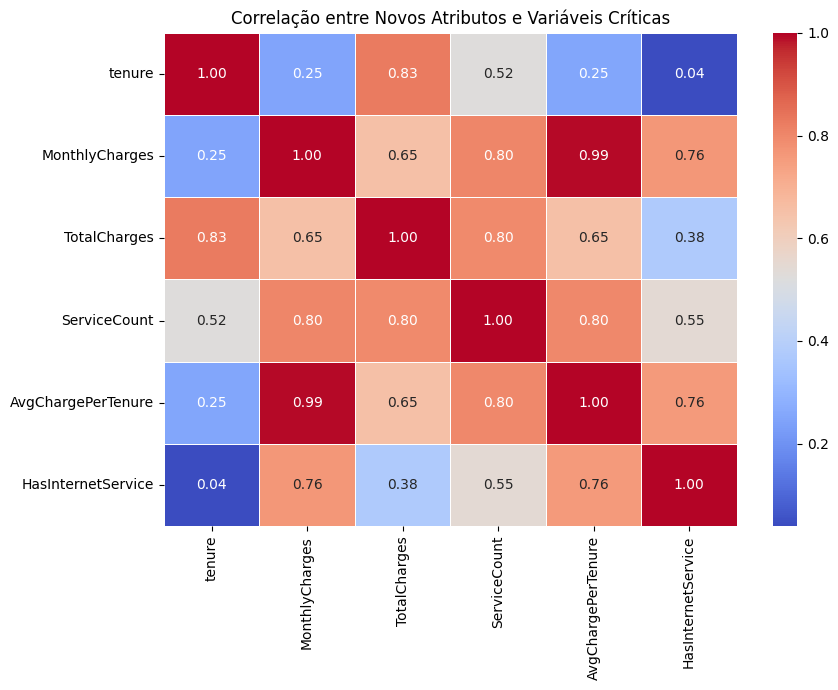

In [46]:
# Heatmap das novas variáveis e variáveis críticas

import seaborn as sns
import matplotlib.pyplot as plt

figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_new_features,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlação entre Novos Atributos e Variáveis Críticas")
plt.tight_layout()

plt.savefig(figures_path / "heatmap_novos_atributos_variaveis_criticas.png", dpi=300)

plt.show()

In [47]:
# Correlações das novas variáveis ordenadas

correlation_pairs = correlation_new_features.unstack().reset_index()
correlation_pairs.columns = ["Variável 1", "Variável 2", "Correlação"]

# Remover autocorrelações
correlation_pairs = correlation_pairs[
    correlation_pairs["Variável 1"] != correlation_pairs["Variável 2"]
]

# Manter apenas pares que envolvem novas variáveis
correlation_pairs = correlation_pairs[
    correlation_pairs["Variável 1"].isin(new_features) |
    correlation_pairs["Variável 2"].isin(new_features)
]

# Remover duplicados
correlation_pairs["Par"] = correlation_pairs.apply(
    lambda row: tuple(sorted([row["Variável 1"], row["Variável 2"]])),
    axis=1
)

correlation_pairs = correlation_pairs.drop_duplicates("Par").drop(columns="Par")

# Ordenar por valor absoluto
correlation_pairs["Correlação Absoluta"] = correlation_pairs["Correlação"].abs()

correlation_pairs = correlation_pairs.sort_values(
    by="Correlação Absoluta",
    ascending=False
)

display(correlation_pairs)

,Variável 1,Variável 2,Correlação,Correlação Absoluta
10,MonthlyCharges,AvgChargePerTenure,0.994355,0.994355
9,MonthlyCharges,ServiceCount,0.802322,0.802322
22,ServiceCount,AvgChargePerTenure,0.797374,0.797374
15,TotalCharges,ServiceCount,0.795854,0.795854
11,MonthlyCharges,HasInternetService,0.763557,0.763557
29,AvgChargePerTenure,HasInternetService,0.758465,0.758465
16,TotalCharges,AvgChargePerTenure,0.651435,0.651435
23,ServiceCount,HasInternetService,0.545546,0.545546
3,tenure,ServiceCount,0.523600,0.523600
17,TotalCharges,HasInternetService,0.375223,0.375223


In [48]:
# Relação das novas variáveis com variáveis categóricas relevantes

categorical_reference_vars = [
    "Contract",
    "InternetService",
    "PaymentMethod"
]

categorical_reference_vars = [
    col for col in categorical_reference_vars if col in df_m2.columns
]

for cat_col in categorical_reference_vars:
    print(f"\nMédia das novas variáveis por categoria de {cat_col}:")
    
    group_summary = df_m2.groupby(cat_col)[new_features].mean().round(2)
    
    display(group_summary)


Média das novas variáveis por categoria de Contract:


,ServiceCount,AvgChargePerTenure,HasInternetService
Contract,,,
Month-to-month,2.84,66.38,0.86
One year,3.82,65.06,0.75
Two year,4.17,60.54,0.62



Média das novas variáveis por categoria de InternetService:


,ServiceCount,AvgChargePerTenure,HasInternetService
InternetService,,,
DSL,3.67,57.98,1.0
Fiber optic,4.18,91.46,1.0
No,1.22,21.05,0.0



Média das novas variáveis por categoria de PaymentMethod:


,ServiceCount,AvgChargePerTenure,HasInternetService
PaymentMethod,,,
Bank transfer (automatic),3.85,67.09,0.78
Credit card (automatic),3.88,66.48,0.78
Electronic check,3.47,76.26,0.95
Mailed check,2.26,43.76,0.54


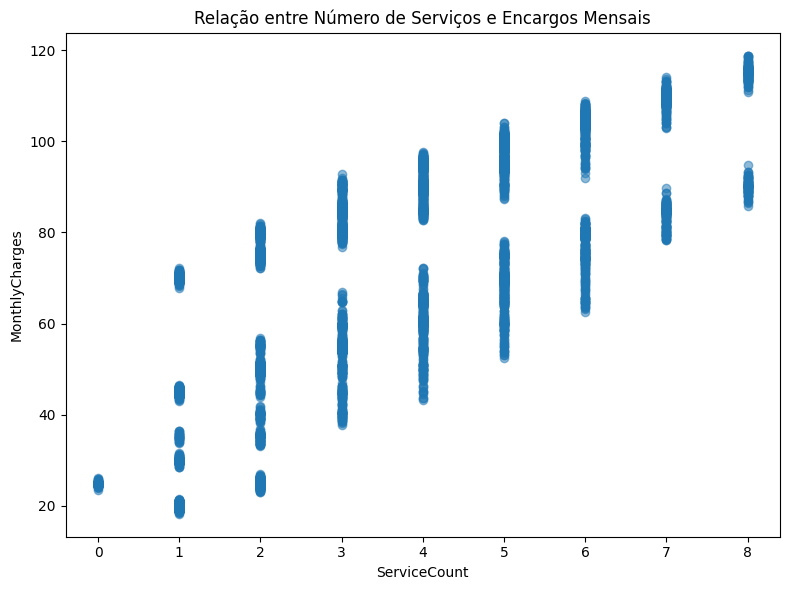

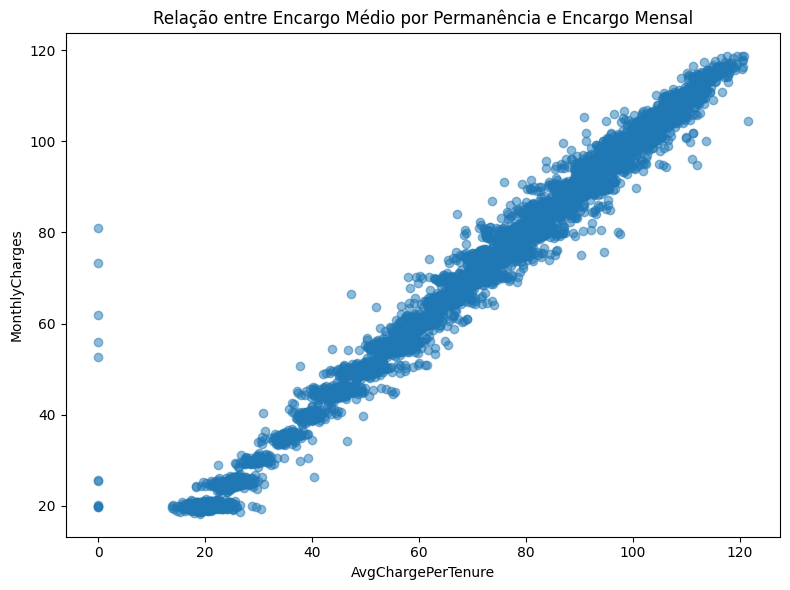

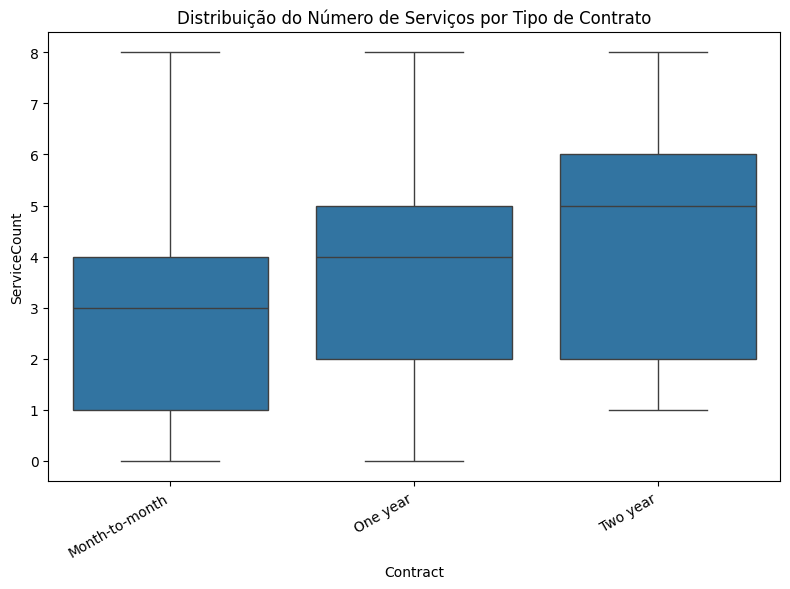

In [49]:
# Scatter plot: ServiceCount vs MonthlyCharges

plt.figure(figsize=(8, 6))

plt.scatter(
    df_m2["ServiceCount"],
    df_m2["MonthlyCharges"],
    alpha=0.5
)

plt.title("Relação entre Número de Serviços e Encargos Mensais")
plt.xlabel("ServiceCount")
plt.ylabel("MonthlyCharges")
plt.tight_layout()

plt.savefig(figures_path / "scatter_servicecount_monthlycharges.png", dpi=300)

plt.show()


# Scatter plot: AvgChargePerTenure vs MonthlyCharges

plt.figure(figsize=(8, 6))

plt.scatter(
    df_m2["AvgChargePerTenure"],
    df_m2["MonthlyCharges"],
    alpha=0.5
)

plt.title("Relação entre Encargo Médio por Permanência e Encargo Mensal")
plt.xlabel("AvgChargePerTenure")
plt.ylabel("MonthlyCharges")
plt.tight_layout()

plt.savefig(figures_path / "scatter_avgchargepertenure_monthlycharges.png", dpi=300)

plt.show()


# Boxplot: ServiceCount por Contract

if "Contract" in df_m2.columns:
    plt.figure(figsize=(8, 6))
    
    sns.boxplot(
        data=df_m2,
        x="Contract",
        y="ServiceCount"
    )
    
    plt.title("Distribuição do Número de Serviços por Tipo de Contrato")
    plt.xlabel("Contract")
    plt.ylabel("ServiceCount")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    
    plt.savefig(figures_path / "boxplot_servicecount_contract.png", dpi=300)
    
    plt.show()

In [50]:
# Guardar dataset com novos atributos

processed_path = Path("data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

output_file = processed_path / "telco_customer_churn_m2_novos_atributos.csv"

df_m2.to_csv(output_file, index=False)

print(f"Dataset com novos atributos guardado em: {output_file}")
print(f"Dimensão final: {df_m2.shape[0]} linhas e {df_m2.shape[1]} colunas")

Dataset com novos atributos guardado em: data/processed/telco_customer_churn_m2_novos_atributos.csv
Dimensão final: 7043 linhas e 28 colunas


### Síntese da criação de novos atributos

Foram criadas novas variáveis com o objetivo de enriquecer a análise de segmentação:

- `ServiceCount`, que representa o número de serviços subscritos pelo cliente;
- `AvgChargePerTenure`, que representa o valor médio acumulado por mês de permanência;
- `HasInternetService`, que identifica se o cliente possui ou não serviço de internet.

Estas variáveis estão alinhadas com o Objetivo SMART, porque ajudam a caracterizar perfis de clientes com base em serviços subscritos, consumo e relação com a empresa.

Após a análise de correlação, observou-se que:

- `ServiceCount` apresentou maior relação com `[preencher com variável]`, com correlação de `[preencher]`;
- `AvgChargePerTenure` apresentou maior relação com `[preencher com variável]`, com correlação de `[preencher]`;
- `HasInternetService` apresentou maior relação com `[preencher com variável]`, com correlação de `[preencher]`.

Como o projeto é não supervisionado, estas variáveis não foram avaliadas contra uma variável-alvo. A sua utilidade será confirmada na fase de modelação, através da análise dos clusters, do Coeficiente de Silhueta e da capacidade de caracterizar os 3 perfis de clientes.

## 10. Seleção de Atributos — Feature Selection

Nesta fase é realizada a seleção final de atributos para a modelação não supervisionada.

Como o projeto não tem variável-alvo, a seleção de atributos não será feita com base na capacidade de prever uma classe. Em vez disso, serão mantidas variáveis alinhadas com o Objetivo SMART e removidas variáveis identificadoras, redundantes, constantes ou com correlação demasiado alta entre si.

A variável `customerID` será removida por ser apenas um identificador. A variável `Churn` também será excluída, uma vez que o objetivo do projeto não é prever abandono, mas sim identificar 3 perfis de clientes.

In [51]:
# Seleção de Atributos — Preparação inicial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler

# Garantir que existe uma cópia da Milestone 2
try:
    df_m2
except NameError:
    df_m2 = df.copy()

# Criar pasta para figuras e dados processados
figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

processed_path = Path("data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

# Garantir que TotalCharges está em formato numérico
df_m2["TotalCharges"] = pd.to_numeric(df_m2["TotalCharges"], errors="coerce")

# Tratar TotalCharges em falta quando tenure = 0
condition_totalcharges_zero = df_m2["TotalCharges"].isna() & (df_m2["tenure"] == 0)
df_m2.loc[condition_totalcharges_zero, "TotalCharges"] = 0

# Caso ainda existam nulos, preencher com mediana
if df_m2["TotalCharges"].isna().sum() > 0:
    df_m2["TotalCharges"] = df_m2["TotalCharges"].fillna(df_m2["TotalCharges"].median())

print("Dimensão inicial de df_m2:")
print(df_m2.shape)

print("\nTotal de valores em falta:")
print(df_m2.isna().sum().sum())

Dimensão inicial de df_m2:
(7043, 28)

Total de valores em falta:
0


In [52]:
# Garantir existência dos novos atributos

# Nova variável: ServiceCount
if "ServiceCount" not in df_m2.columns:
    service_columns = [
        "PhoneService",
        "MultipleLines",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"
    ]

    service_columns = [col for col in service_columns if col in df_m2.columns]

    df_m2["ServiceCount"] = 0

    for col in service_columns:
        df_m2["ServiceCount"] += (df_m2[col] == "Yes").astype(int)


# Nova variável: AvgChargePerTenure
if "AvgChargePerTenure" not in df_m2.columns:
    df_m2["AvgChargePerTenure"] = np.where(
        df_m2["tenure"] > 0,
        df_m2["TotalCharges"] / df_m2["tenure"],
        0
    )


# Nova variável: HasInternetService
if "HasInternetService" not in df_m2.columns and "InternetService" in df_m2.columns:
    df_m2["HasInternetService"] = np.where(
        df_m2["InternetService"] != "No",
        1,
        0
    )

new_features = [
    "ServiceCount",
    "AvgChargePerTenure",
    "HasInternetService"
]

new_features = [col for col in new_features if col in df_m2.columns]

print("Novos atributos disponíveis:")
print(new_features)

display(df_m2[new_features].head())

Novos atributos disponíveis:
['ServiceCount', 'AvgChargePerTenure', 'HasInternetService']


,ServiceCount,AvgChargePerTenure,HasInternetService
0,1,29.850000,1
1,3,55.573529,1
2,3,54.075000,1
3,3,40.905556,1
4,1,75.825000,1


In [53]:
# Seleção inicial de variáveis alinhadas com o Objetivo SMART

# Variáveis demográficas
demographic_vars = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

# Variáveis contratuais
contractual_vars = [
    "tenure",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

# Variáveis de serviços subscritos
service_vars = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Variáveis de consumo / valor económico
consumption_vars = [
    "MonthlyCharges",
    "TotalCharges"
]

# Novos atributos criados
engineered_vars = [
    "ServiceCount",
    "AvgChargePerTenure",
    "HasInternetService"
]

# Juntar todas as variáveis relevantes para segmentação
selected_vars = (
    demographic_vars
    + contractual_vars
    + service_vars
    + consumption_vars
    + engineered_vars
)

# Garantir que só entram colunas existentes no dataframe
selected_vars = [col for col in selected_vars if col in df_m2.columns]

# Remover variáveis que não entram na segmentação
selected_vars = [
    col for col in selected_vars
    if col not in ["customerID", "Churn"]
]

# Criar dataframe de atributos para feature selection
df_features = df_m2[selected_vars].copy()

print("Variáveis selecionadas para feature selection:")
print(selected_vars)

print("\nDimensão de df_features:")
print(df_features.shape)

display(df_features.head())

Variáveis selecionadas para feature selection:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'AvgChargePerTenure', 'HasInternetService']

Dimensão de df_features:
(7043, 22)


,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaperlessBilling,PaymentMethod,PhoneService,MultipleLines,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,TotalCharges,ServiceCount,AvgChargePerTenure,HasInternetService
0,Female,0,Yes,No,1,Month-to-month,Yes,Electronic check,No,No phone service,...,Yes,No,No,No,No,29.85,29.85,1,29.850000,1
1,Male,0,No,No,34,One year,No,Mailed check,Yes,No,...,No,Yes,No,No,No,56.95,1889.50,3,55.573529,1
2,Male,0,No,No,2,Month-to-month,Yes,Mailed check,Yes,No,...,Yes,No,No,No,No,53.85,108.15,3,54.075000,1
3,Male,0,No,No,45,One year,No,Bank transfer (automatic),No,No phone service,...,No,Yes,Yes,No,No,42.30,1840.75,3,40.905556,1
4,Female,0,No,No,2,Month-to-month,Yes,Electronic check,Yes,No,...,No,No,No,No,No,70.70,151.65,1,75.825000,1


In [54]:
# One-Hot Encoding com redução de redundância

categorical_features = df_features.select_dtypes(include=["object"]).columns.tolist()

print("Variáveis categóricas para One-Hot Encoding:")
print(categorical_features)

df_encoded = pd.get_dummies(
    df_features,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("\nDimensão antes do One-Hot Encoding:")
print(df_features.shape)

print("\nDimensão depois do One-Hot Encoding:")
print(df_encoded.shape)

display(df_encoded.head())

Variáveis categóricas para One-Hot Encoding:
['gender', 'Partner', 'Dependents', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

Dimensão antes do One-Hot Encoding:
(7043, 22)

Dimensão depois do One-Hot Encoding:
(7043, 33)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ServiceCount,AvgChargePerTenure,HasInternetService,gender_Male,Partner_Yes,Dependents_Yes,...,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,1,29.85,29.85,1,29.850000,1,0,1,0,...,0,1,0,0,0,0,0,0,0,0
1,0,34,56.95,1889.50,3,55.573529,1,1,0,0,...,0,0,0,1,0,0,0,0,0,0
2,0,2,53.85,108.15,3,54.075000,1,1,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,45,42.30,1840.75,3,40.905556,1,1,0,0,...,0,0,0,1,0,1,0,0,0,0
4,0,2,70.70,151.65,1,75.825000,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [55]:
# Remoção de variáveis constantes

nunique = df_encoded.nunique()

constant_columns = nunique[nunique <= 1].index.tolist()

print("Colunas constantes removidas:")
print(constant_columns)

df_selected = df_encoded.drop(columns=constant_columns)

print("\nDimensão após remoção de colunas constantes:")
print(df_selected.shape)

Colunas constantes removidas:
[]

Dimensão após remoção de colunas constantes:
(7043, 33)


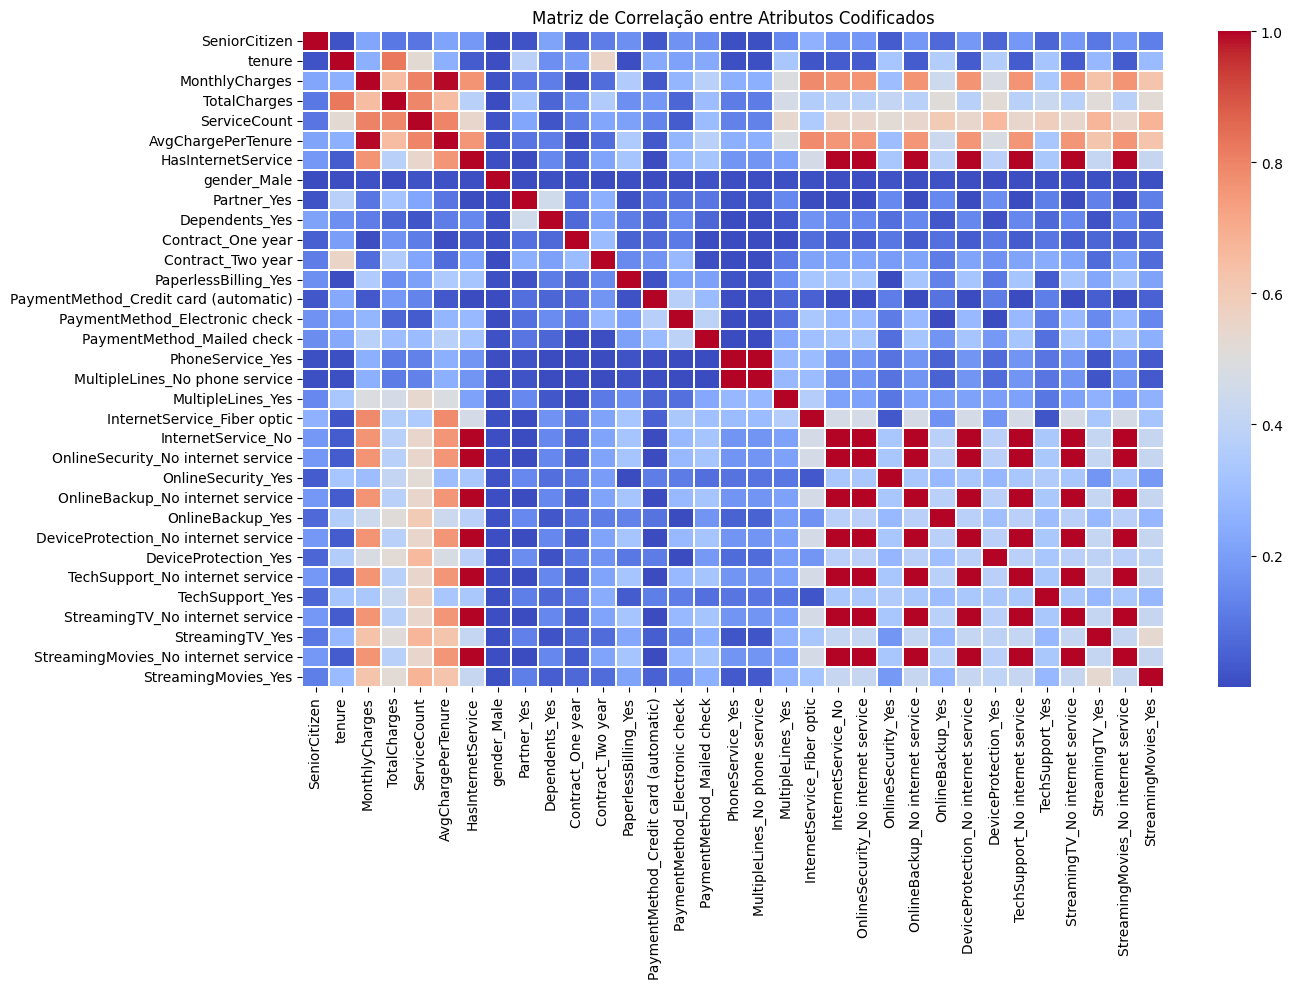

In [56]:
# Matriz de correlação para seleção de atributos

corr_matrix = df_selected.corr().abs()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    linewidths=0.2
)

plt.title("Matriz de Correlação entre Atributos Codificados")
plt.tight_layout()

plt.savefig(figures_path / "heatmap_feature_selection_correlacao.png", dpi=300)

plt.show()

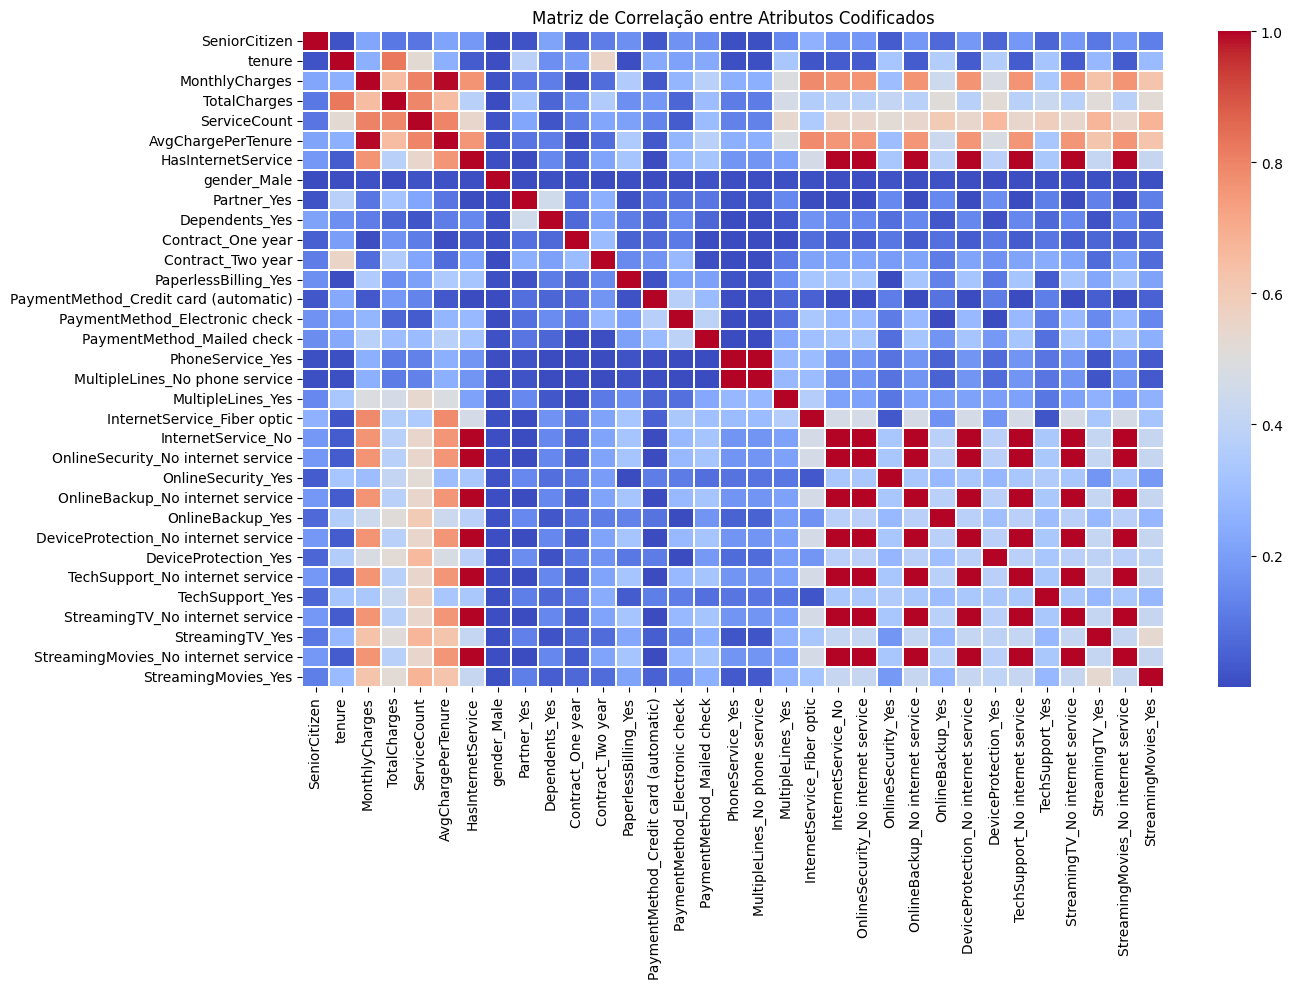

Pares com correlação elevada encontrados:


,Variável 1,Variável 2,Correlação absoluta
3,HasInternetService,OnlineSecurity_No internet service,1.000000
2,HasInternetService,InternetService_No,1.000000
5,HasInternetService,OnlineBackup_No internet service,1.000000
8,HasInternetService,DeviceProtection_No internet service,1.000000
12,HasInternetService,TechSupport_No internet service,1.000000
17,HasInternetService,StreamingTV_No internet service,1.000000
23,HasInternetService,StreamingMovies_No internet service,1.000000
4,InternetService_No,OnlineSecurity_No internet service,1.000000
9,InternetService_No,DeviceProtection_No internet service,1.000000
6,InternetService_No,OnlineBackup_No internet service,1.000000



Colunas removidas por correlação elevada:
['AvgChargePerTenure', 'MultipleLines_No phone service', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']

Dimensão antes da remoção por correlação:
(7043, 33)

Dimensão depois da remoção por correlação:
(7043, 24)


In [57]:
# Correlação e remoção de variáveis com correlação elevada

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Garantir que a pasta de figuras existe
figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

# Limite de correlação definido para considerar redundância
correlation_threshold = 0.90

# Calcular matriz de correlação absoluta
corr_matrix = df_selected.corr().abs()

# Criar heatmap da matriz de correlação
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    linewidths=0.2
)

plt.title("Matriz de Correlação entre Atributos Codificados")
plt.tight_layout()

plt.savefig(figures_path / "heatmap_feature_selection_correlacao.png", dpi=300)

plt.show()

# Obter apenas a parte superior da matriz para evitar pares duplicados
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Identificar pares com correlação elevada
high_corr_pairs = []

for column in upper_triangle.columns:
    correlated_columns = upper_triangle.index[
        upper_triangle[column] > correlation_threshold
    ].tolist()
    
    for correlated_column in correlated_columns:
        high_corr_pairs.append({
            "Variável 1": correlated_column,
            "Variável 2": column,
            "Correlação absoluta": upper_triangle.loc[correlated_column, column]
        })

high_corr_pairs_df = pd.DataFrame(high_corr_pairs)

if len(high_corr_pairs_df) > 0:
    high_corr_pairs_df = high_corr_pairs_df.sort_values(
        by="Correlação absoluta",
        ascending=False
    )
    print("Pares com correlação elevada encontrados:")
    display(high_corr_pairs_df)
else:
    print(f"Não foram encontrados pares com correlação absoluta superior a {correlation_threshold}.")

# Remover uma das variáveis de cada par com correlação elevada
columns_to_drop_corr = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > correlation_threshold)
]

print("\nColunas removidas por correlação elevada:")
print(columns_to_drop_corr)

df_selected_no_corr = df_selected.drop(columns=columns_to_drop_corr)

print("\nDimensão antes da remoção por correlação:")
print(df_selected.shape)

print("\nDimensão depois da remoção por correlação:")
print(df_selected_no_corr.shape)

In [58]:
# Escalonamento dos atributos finais

df_final_features = df_selected_no_corr.copy()

# Variáveis contínuas/count que devem ser escalonadas se ainda existirem
continuous_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ServiceCount",
    "AvgChargePerTenure"
]

continuous_features = [
    col for col in continuous_features
    if col in df_final_features.columns
]

scaler = StandardScaler()

df_final_features[continuous_features] = scaler.fit_transform(
    df_final_features[continuous_features]
)

print("Variáveis escalonadas:")
print(continuous_features)

print("\nDimensão final do dataset processado:")
print(df_final_features.shape)

display(df_final_features.head())

Variáveis escalonadas:
['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount']

Dimensão final do dataset processado:
(7043, 24)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ServiceCount,HasInternetService,gender_Male,Partner_Yes,Dependents_Yes,Contract_One year,...,PaymentMethod_Mailed check,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes
0,0,-1.277445,-1.160323,-0.992611,-1.145997,1,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0.066327,-0.259629,-0.172165,-0.176011,1,1,0,0,1,...,1,1,0,0,1,0,1,0,0,0
2,0,-1.236724,-0.362660,-0.958066,-0.176011,1,1,0,0,0,...,1,1,0,0,1,1,0,0,0,0
3,0,0.514251,-0.746535,-0.193672,-0.176011,1,1,0,0,1,...,0,0,0,0,1,0,1,1,0,0
4,0,-1.236724,0.197365,-0.938874,-1.145997,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0


In [59]:
# Validação final do dataset processado

non_numeric_cols = df_final_features.select_dtypes(exclude=[np.number]).columns.tolist()
missing_values = df_final_features.isna().sum().sum()

print("Colunas não numéricas no dataset final:")
print(non_numeric_cols)

print("\nTotal de valores em falta no dataset final:")
print(missing_values)

print("\nChurn está no dataset final?")
print("Churn" in df_final_features.columns)

print("\ncustomerID está no dataset final?")
print("customerID" in df_final_features.columns)

print("\nDimensão final:")
print(df_final_features.shape)

Colunas não numéricas no dataset final:
[]

Total de valores em falta no dataset final:
0

Churn está no dataset final?
False

customerID está no dataset final?
False

Dimensão final:
(7043, 24)


In [60]:
# Guardar dataset processado final

output_file = processed_path / "telco_customer_churn_m2_final_processado.csv"

df_final_features.to_csv(output_file, index=False)

print(f"Dataset processado guardado em: {output_file}")
print(f"Dimensão final: {df_final_features.shape[0]} linhas e {df_final_features.shape[1]} colunas")

# Guardar lista de atributos finais

features_file = processed_path / "lista_atributos_finais_m2.csv"

final_features_list = pd.DataFrame({
    "Atributo final": df_final_features.columns
})

final_features_list.to_csv(features_file, index=False)

print(f"Lista de atributos finais guardada em: {features_file}")

display(final_features_list)



# Guardar tabela de variáveis removidas

removed_features = pd.DataFrame({
    "Variável removida": constant_columns + columns_to_drop_corr,
    "Motivo": (
        ["Coluna constante"] * len(constant_columns)
        + ["Correlação elevada"] * len(columns_to_drop_corr)
    )
})

removed_features_file = processed_path / "atributos_removidos_m2.csv"

removed_features.to_csv(removed_features_file, index=False)

print(f"Tabela de atributos removidos guardada em: {removed_features_file}")

display(removed_features)

Dataset processado guardado em: data/processed/telco_customer_churn_m2_final_processado.csv
Dimensão final: 7043 linhas e 24 colunas
Lista de atributos finais guardada em: data/processed/lista_atributos_finais_m2.csv


,Atributo final
0,SeniorCitizen
1,tenure
2,MonthlyCharges
3,TotalCharges
4,ServiceCount
5,HasInternetService
6,gender_Male
7,Partner_Yes
8,Dependents_Yes
9,Contract_One year


Tabela de atributos removidos guardada em: data/processed/atributos_removidos_m2.csv


,Variável removida,Motivo
0,AvgChargePerTenure,Correlação elevada
1,MultipleLines_No phone service,Correlação elevada
2,InternetService_No,Correlação elevada
3,OnlineSecurity_No internet service,Correlação elevada
4,OnlineBackup_No internet service,Correlação elevada
5,DeviceProtection_No internet service,Correlação elevada
6,TechSupport_No internet service,Correlação elevada
7,StreamingTV_No internet service,Correlação elevada
8,StreamingMovies_No internet service,Correlação elevada
